# Laboratorio 4. Análisis de Datos Geoespaciales

**Ihan Marroquín - 23108**  
**Diego Patzán - 23525**

Este cuaderno estudia la señal estimada de cianobacteria en los lagos Atitlán y
Amatitlán. La idea no es reemplazar una muestra de agua, sino observar dónde y
cuándo conviene prestar más atención. Se trabajó únicamente con las 22 fechas
indicadas en la guía y con las bandas necesarias de Sentinel-2 L2A.

## Preparación

El análisis usa una resolución de 120 metros. Con ella se conservan la forma y
los contrastes principales de ambos lagos, pero la descarga se mantiene ligera.
Para repetir la consulta basta cambiar `ACTUALIZAR_DATOS` a `True`.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

carpeta_actual = Path.cwd().resolve()
RAIZ = carpeta_actual.parent if carpeta_actual.name == "notebooks" else carpeta_actual
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.analisis_completo import CARPETA_FIGURAS, ejecutar_pipeline

ACTUALIZAR_DATOS = False
resultados = ejecutar_pipeline(forzar_descarga=ACTUALIZAR_DATOS)
metricas = resultados["metricas"].copy()
correlaciones = resultados["correlaciones"].copy()
resumen = resultados["resumen"].copy()
estacionalidad = resultados["estacionalidad"].copy()

print(f"Proyecto: {RAIZ}")
print(f"Observaciones procesadas: {len(metricas)}")

Proyecto: /home/DiegoPatzan/Documents/UVG/DATA/lab4_geo
Observaciones procesadas: 22


## 1. Conexión con la API de Sentinel-2

Se conserva la conexión de openEO con Copernicus y se consulta el catálogo STAC de Planetary Computer, que
publica escenas Sentinel-2 L2A y permite leer solamente la ventana de los lagos.
No se guardan contraseñas ni se descargan escenas completas.

In [2]:
pd.Series({
    "openEO": "https://openeo.dataspace.copernicus.eu",
    "STAC": "https://planetarycomputer.microsoft.com/api/stac/v1",
    "colección": "sentinel-2-l2a",
}, name="Configuración")

openEO                  https://openeo.dataspace.copernicus.eu
STAC         https://planetarycomputer.microsoft.com/api/st...
colección                                       sentinel-2-l2a
Name: Configuración, dtype: str

## 2. Obtención de los datos necesarios

Por fecha se leen B02, B03, B04, B08 y la capa de calidad SCL. Se retiran nubes,
sombras, nieve y valores inválidos. La tabla deja trazabilidad de la escena y de
los píxeles de agua que realmente entraron al cálculo.

In [3]:
display(metricas[[
    "lago", "fecha", "escena", "nubosidad_escena_pct",
    "pixeles_agua_validos",
]].round(2))

,lago,fecha,escena,nubosidad_escena_pct,pixeles_agua_validos
0,Amatitlan,2025-01-28,S2B_MSIL2A_20250128T162439_R040_T15PYS_2025012...,13.53,821
1,Amatitlan,2025-04-15,S2A_MSIL2A_20250415T162701_R040_T15PYS_2025041...,5.50,884
2,Amatitlan,2025-04-28,S2B_MSIL2A_20250428T161829_R040_T15PYS_2025042...,12.33,850
3,Amatitlan,2025-11-24,S2B_MSIL2A_20251124T162519_R040_T15PYS_2025112...,15.08,810
4,Amatitlan,2026-01-08,S2C_MSIL2A_20260108T162651_R040_T15PYS_2026010...,1.20,757
5,Amatitlan,2026-02-02,S2B_MSIL2A_20260202T162409_R040_T15PYS_2026020...,0.39,757
6,Amatitlan,2026-02-07,S2C_MSIL2A_20260207T162441_R040_T15PYS_2026020...,23.73,825
7,Amatitlan,2026-03-29,S2C_MSIL2A_20260329T161851_R040_T15PYS_2026032...,6.58,884
8,Amatitlan,2026-04-13,S2B_MSIL2A_20260413T161829_R040_T15PYS_2026041...,10.61,916
9,Amatitlan,2026-04-28,S2C_MSIL2A_20260428T161901_R040_T15PYS_2026042...,4.96,723


## 3. Cálculo de NDVI, NDWI y cianobacteria

- **NDVI** ayuda a reconocer vegetación y bordes.
- **NDWI** resalta el agua y sirve como máscara del lago.
- **Cya** usa la ecuación de Se2WaQ:

`Cya = 115530.31 × ((B03 × B04) / B02) ^ 2.38`

La escala se limita a 0-100, como la visualización original. Un valor alto es
una señal de vigilancia, no una confirmación de toxicidad.

In [4]:
display(metricas[[
    "lago", "fecha", "ndvi_promedio", "ndwi_promedio",
    "cianobacteria_promedio", "cianobacteria_mediana",
]].round(3))

,lago,fecha,ndvi_promedio,ndwi_promedio,cianobacteria_promedio,cianobacteria_mediana
0,Amatitlan,2025-01-28,-0.357,0.575,8.717,6.794
1,Amatitlan,2025-04-15,-0.078,0.262,95.076,100.000
2,Amatitlan,2025-04-28,-0.047,0.264,95.328,100.000
3,Amatitlan,2025-11-24,-0.367,0.518,10.483,7.014
4,Amatitlan,2026-01-08,-0.111,0.386,18.155,14.969
5,Amatitlan,2026-02-02,-0.053,0.167,14.913,12.261
6,Amatitlan,2026-02-07,-0.189,0.382,8.764,7.719
7,Amatitlan,2026-03-29,-0.064,0.300,96.243,100.000
8,Amatitlan,2026-04-13,-0.015,0.263,98.896,100.000
9,Amatitlan,2026-04-28,0.005,0.278,98.207,100.000


## 4. Análisis temporal

La primera línea muestra el promedio por fecha. La segunda indica qué porcentaje
del agua válida supera Cya 20. Ver ambas evita confundir un foco pequeño e
intenso con una señal extendida por casi todo el lago.

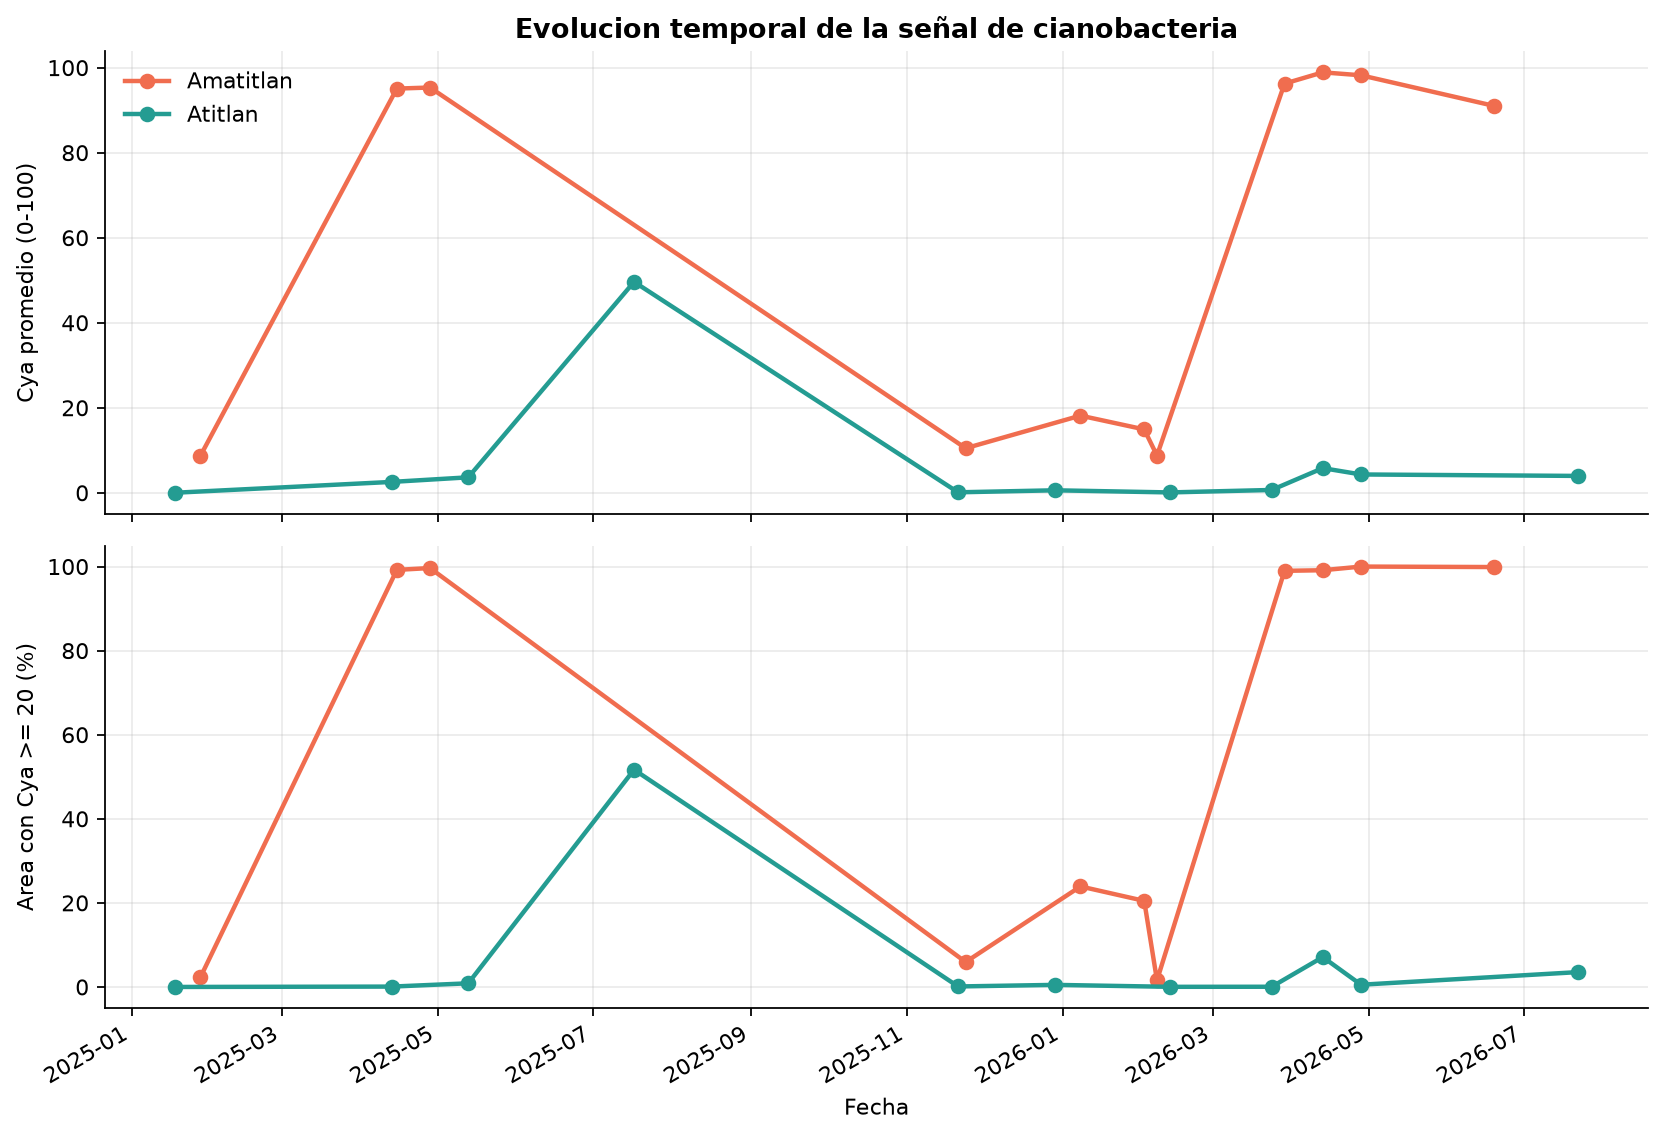

,lago,fecha,cianobacteria_promedio,area_cya_alta_pct
8,Amatitlan,2026-04-13,98.90,99.13
14,Atitlan,2025-07-17,49.62,51.68


In [5]:
display(Image(filename=str(CARPETA_FIGURAS / "evolucion_temporal.png"), width=900))
picos = metricas.loc[
    metricas.groupby("lago")["cianobacteria_promedio"].idxmax(),
    ["lago", "fecha", "cianobacteria_promedio", "area_cya_alta_pct"],
]
display(picos.round(2))

Amatitlán alterna periodos bajos con episodios muy extendidos y cercanos al
límite superior de la escala. Su máximo promedio aparece el 13 de abril de 2026
y la mayor extensión el 28 de abril de 2026. Atitlán permanece bajo en la mayor
parte del periodo, pero el 17 de julio de 2025 presenta un aumento marcado. Esa
fecha tiene menos píxeles válidos y debe interpretarse con más cautela.

## 5. Análisis espacial

Los mosaicos comparan todas las fechas usando la misma escala. Los mapas de
persistencia resumen el porcentaje de observaciones en que cada zona superó el
umbral Cya 20.

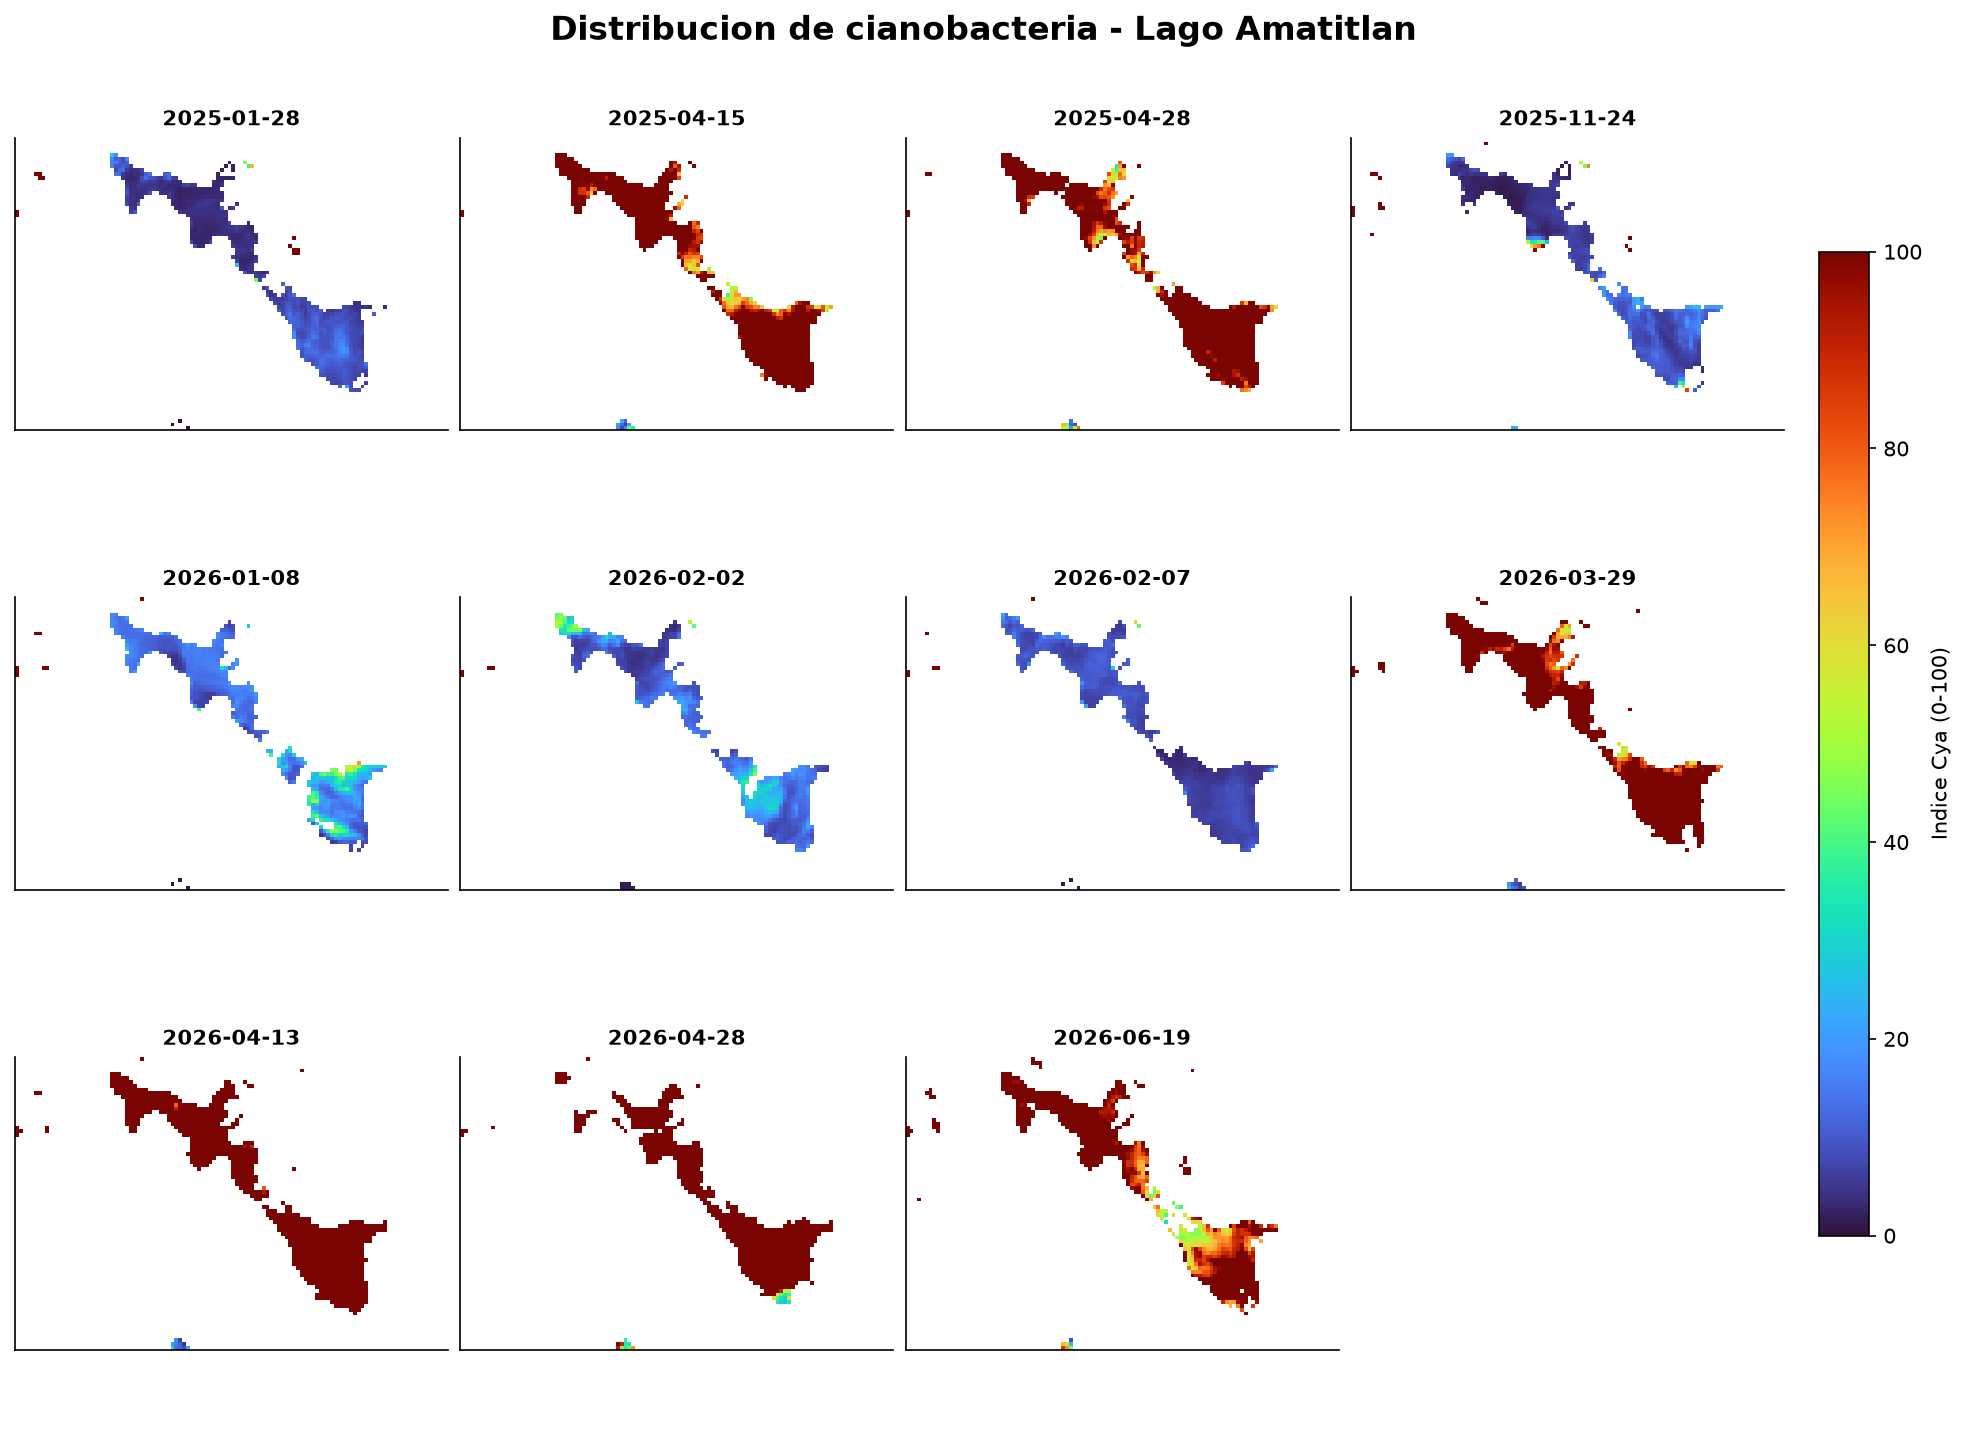

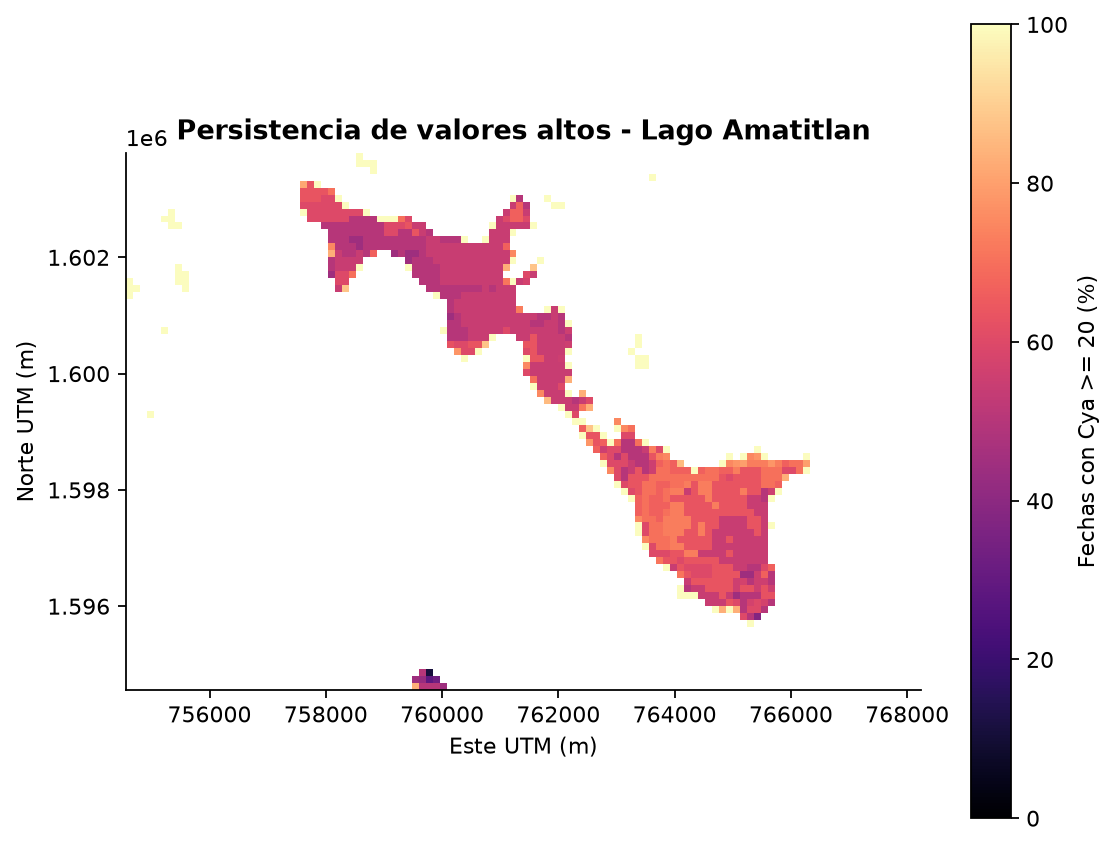

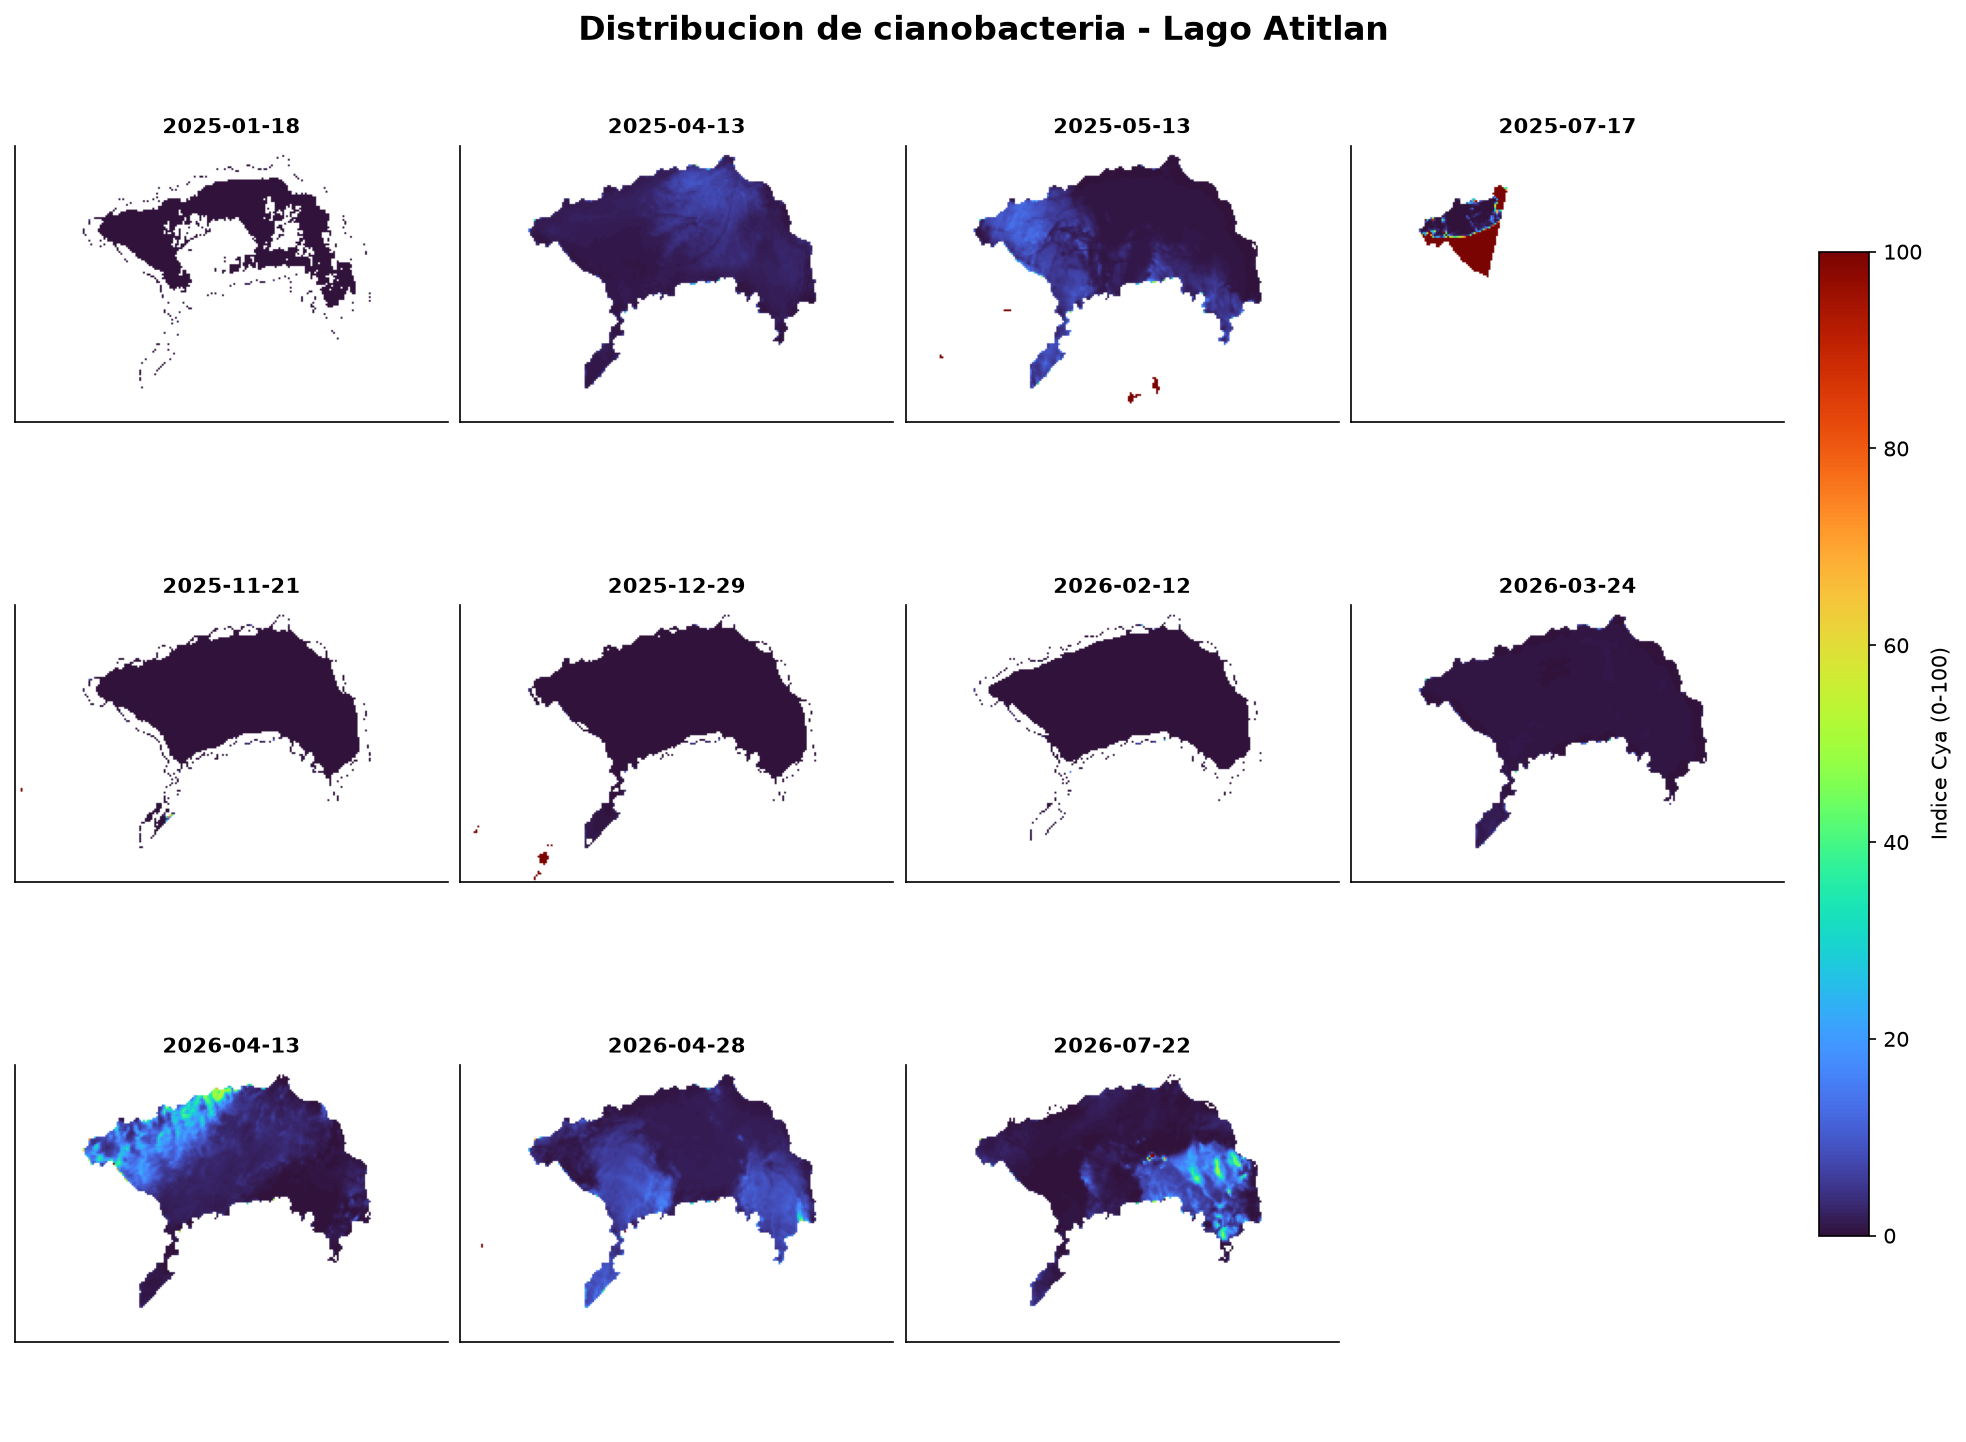

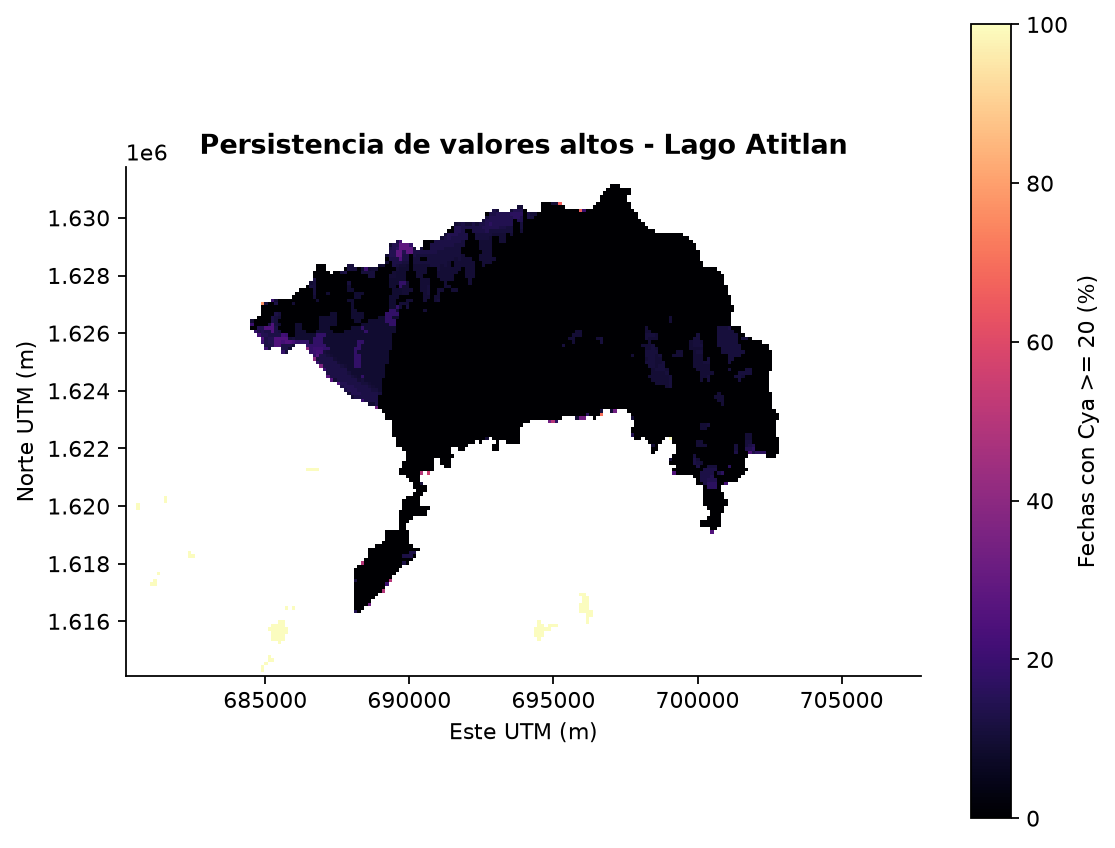

In [6]:
for lago in ("amatitlan", "atitlan"):
    display(Image(filename=str(CARPETA_FIGURAS / f"mapas_cianobacteria_{lago}.png"), width=950))
    display(Image(filename=str(CARPETA_FIGURAS / f"persistencia_{lago}.png"), width=600))

En Amatitlán la señal alta se repite en ambos cuerpos principales y no queda
reducida a un único punto. En Atitlán los valores altos son menos persistentes y
se concentran en observaciones concretas. Los pequeños fragmentos aislados fuera
del contorno principal provienen de la máscara espectral y no se interpretan
como parte del lago.

## 6. Correlación con NDVI y NDWI

Se usó una muestra reproducible de píxeles de todas las fechas. Spearman ayuda a
describir relaciones que no necesariamente forman una línea recta. La cantidad
de puntos vuelve detectables relaciones pequeñas, por eso importa más el tamaño
del coeficiente que el valor p.

,lago,indice,n,pearson_r,pearson_p,spearman_r,spearman_p
0,Amatitlan,NDVI,9090,0.4625,0.0,0.5362,0.0
1,Amatitlan,NDWI,9090,-0.3504,0.0,-0.4201,0.0
2,Atitlan,NDVI,31128,-0.0249,0.0,-0.3459,0.0
3,Atitlan,NDWI,31128,-0.4370,0.0,-0.9057,0.0


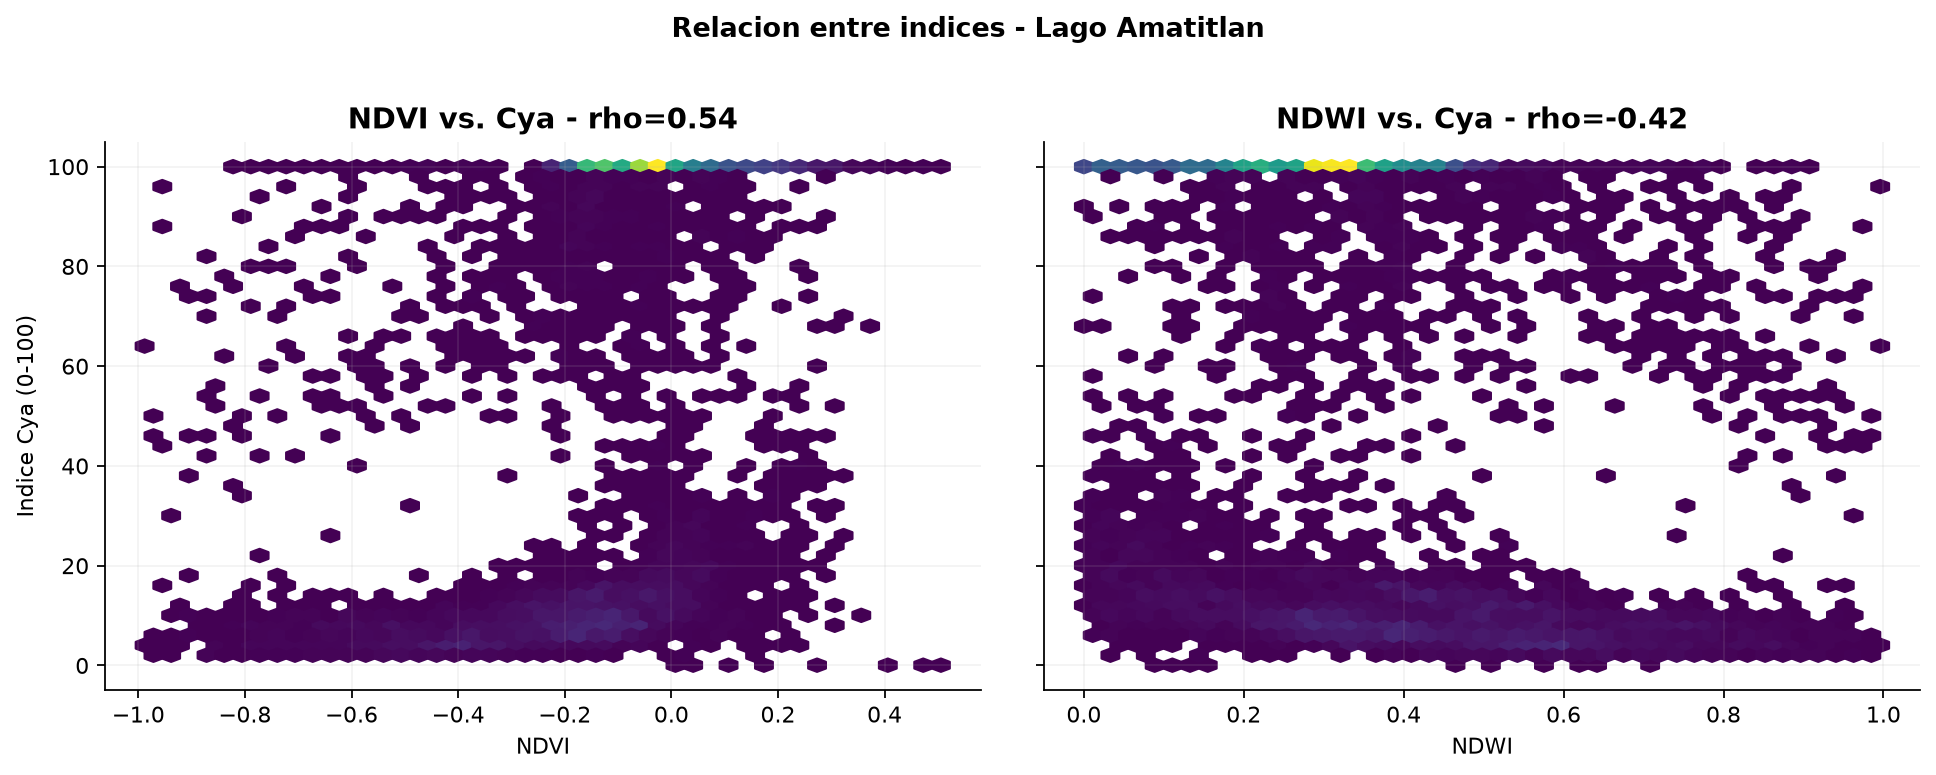

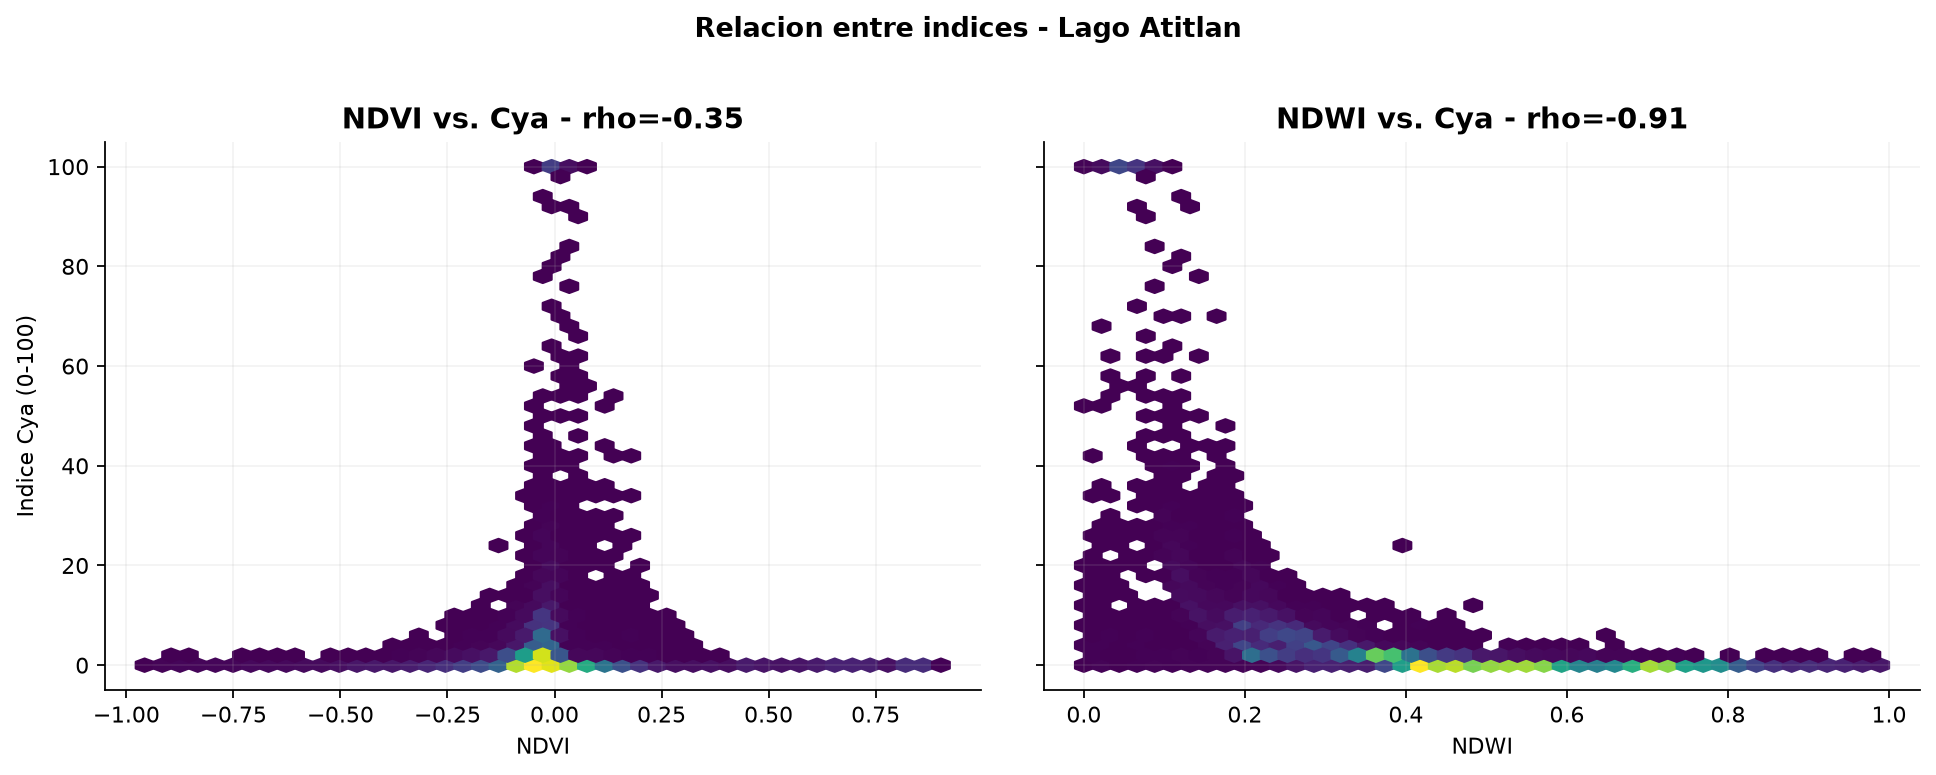

In [7]:
display(correlaciones.round(4))
for lago in ("amatitlan", "atitlan"):
    display(Image(filename=str(CARPETA_FIGURAS / f"correlaciones_{lago}.png"), width=850))

In [8]:
for lago in ("Amatitlan", "Atitlan"):
    fila = correlaciones[correlaciones["lago"] == lago].set_index("indice")
    print(
        f"{lago}: Cya tiene una relación de Spearman "
        f"{fila.loc['NDVI', 'spearman_r']:.2f} con NDVI y "
        f"{fila.loc['NDWI', 'spearman_r']:.2f} con NDWI."
    )

Amatitlan: Cya tiene una relación de Spearman 0.54 con NDVI y -0.42 con NDWI.
Atitlan: Cya tiene una relación de Spearman -0.35 con NDVI y -0.91 con NDWI.


## 7. Comparación entre los lagos

Amatitlán muestra mayor intensidad media y una proporción mucho mayor de agua
por encima del umbral. Atitlán tiene una señal generalmente baja, interrumpida
por un episodio fuerte en julio de 2025. La diferencia es compatible con la
mayor presión urbana y entrada de nutrientes alrededor de Amatitlán, pero las
imágenes por sí solas no demuestran la causa.

In [9]:
display(resumen.round(2))

,lago,promedio_periodo,mediana_periodo,fecha_maxima,valor_maximo,fechas_pico_iqr,area_alta_promedio_pct
0,Amatitlan,57.80,91.03,2026-04-13,98.90,0,59.19
1,Atitlan,6.49,2.56,2025-07-17,49.62,1,5.86


## 8. Análisis exploratorio adicional

Además del promedio se comparó la distribución completa, el cambio entre la
primera y la última fecha, la persistencia de zonas altas y una separación
descriptiva entre temporada seca y lluviosa.

,lago,temporada,observaciones,cya_promedio,area_alta_promedio_pct
0,Amatitlan,Lluviosa,1,91.03,99.88
1,Amatitlan,Seca,10,54.48,55.12
2,Atitlan,Lluviosa,3,19.08,18.69
3,Atitlan,Seca,8,1.77,1.05


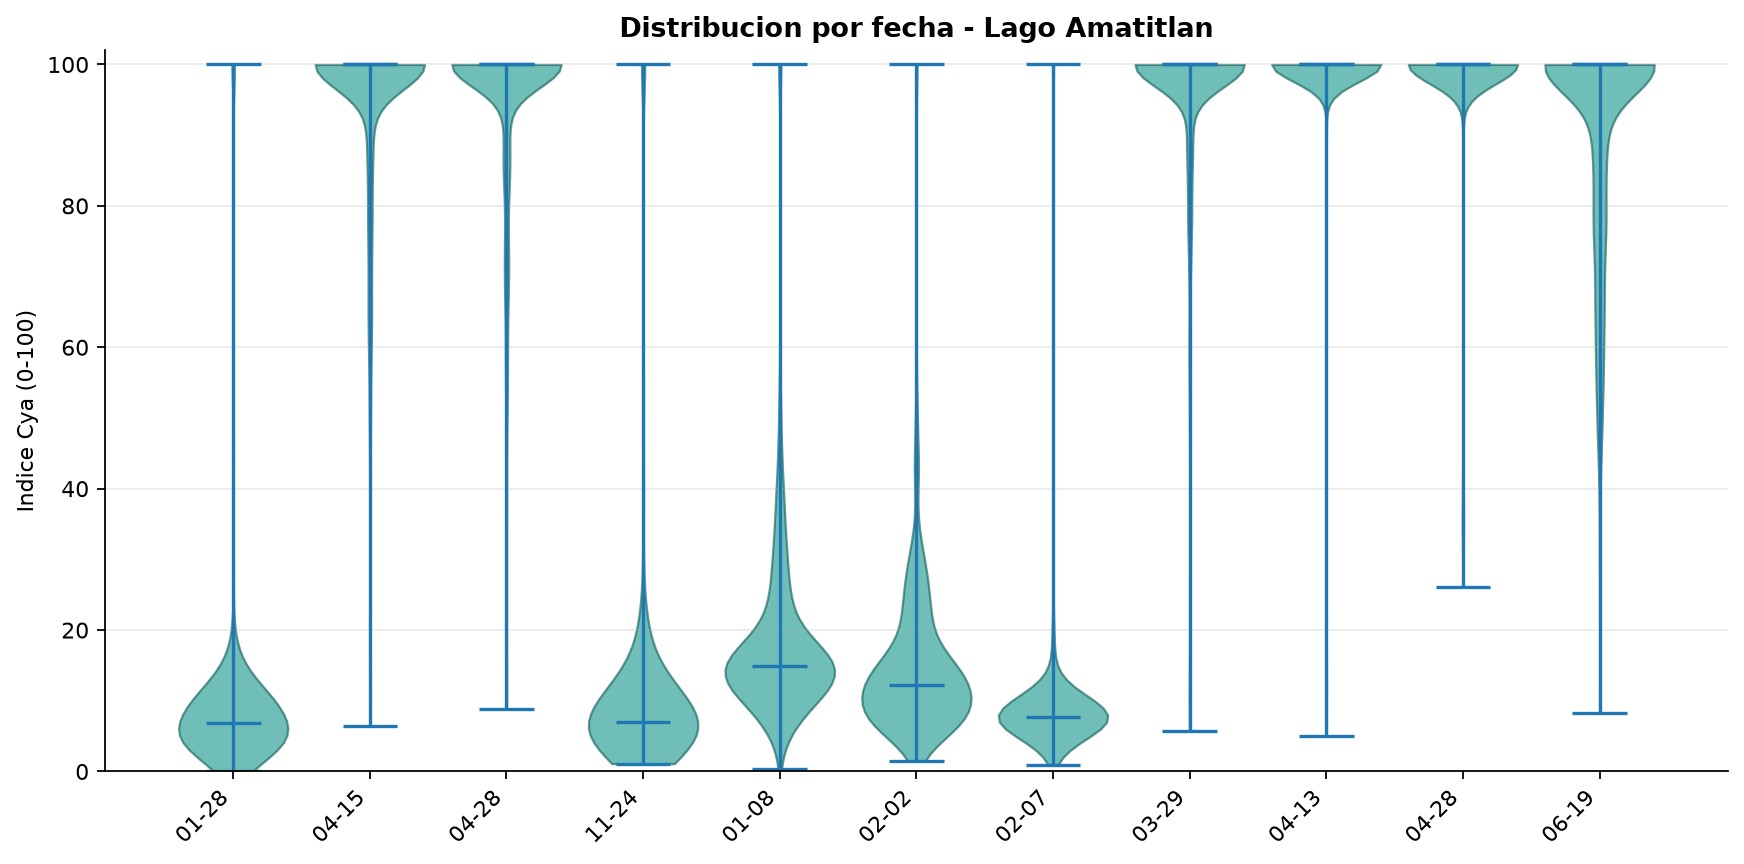

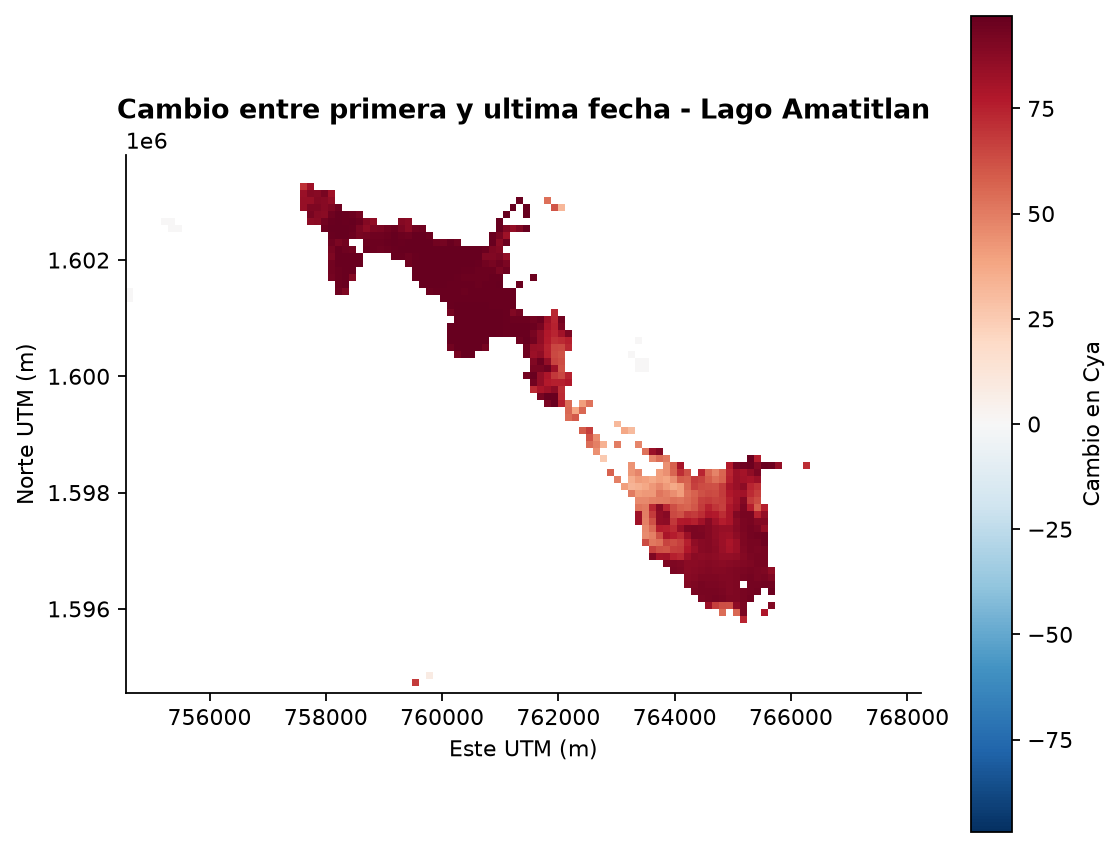

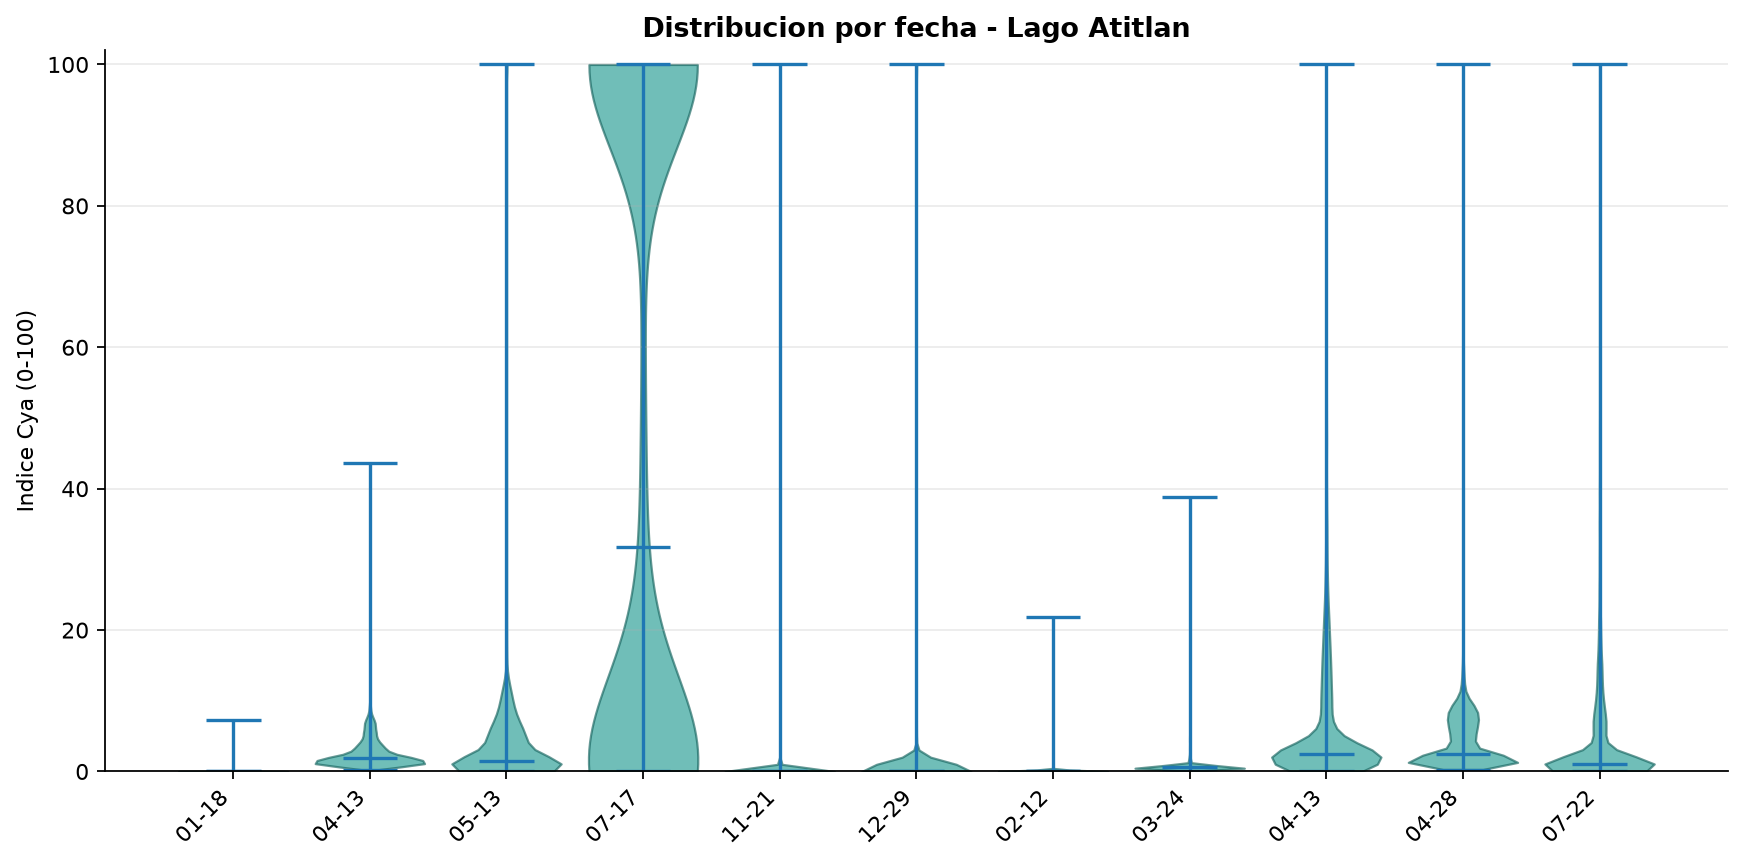

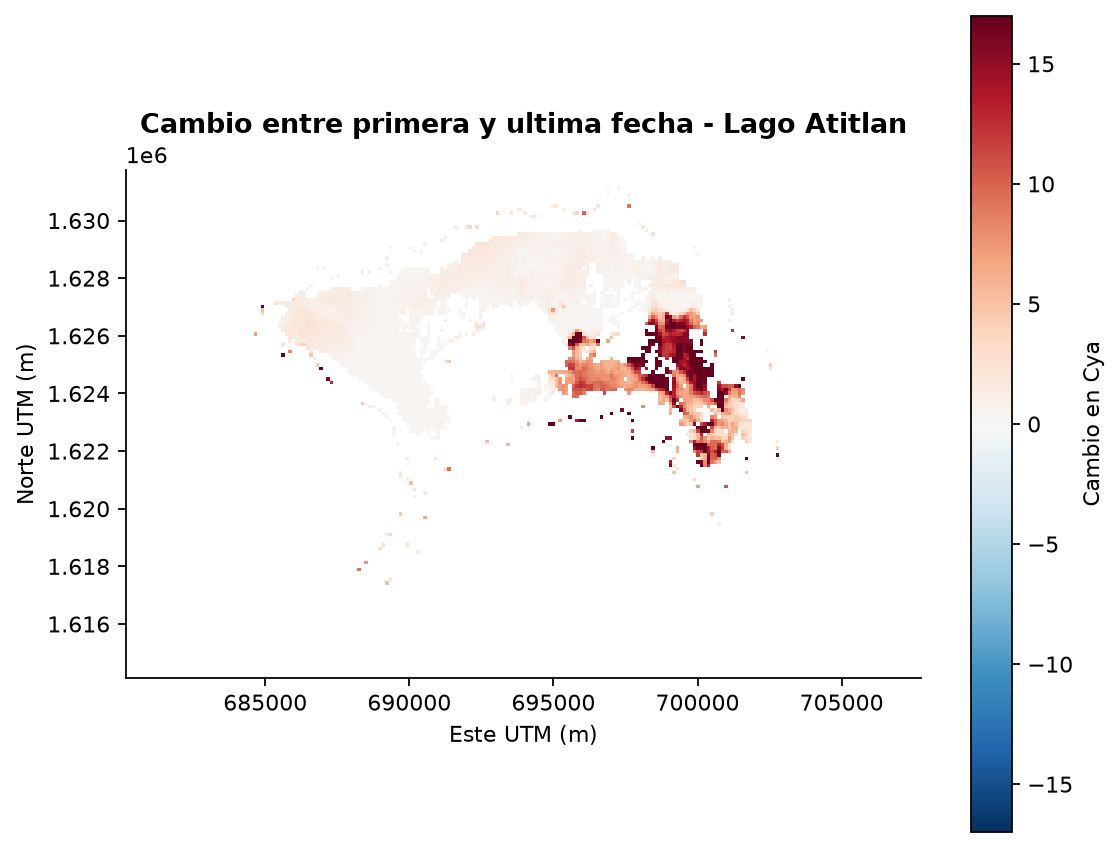

In [10]:
display(estacionalidad.round(2))
for lago in ("amatitlan", "atitlan"):
    display(Image(filename=str(CARPETA_FIGURAS / f"distribuciones_{lago}.png"), width=900))
    display(Image(filename=str(CARPETA_FIGURAS / f"diferencia_{lago}.png"), width=600))

La comparación por temporada debe leerse con prudencia: las fechas no están
espaciadas mensualmente y Amatitlán solo tiene una observación de época lluviosa.
Sí se observa que las distribuciones cambian con fuerza entre fechas y que
Amatitlán conserva una presencia alta en una fracción mucho mayor del lago.

## Conclusiones

1. Amatitlán presenta la señal más intensa, extensa y persistente del periodo.
2. Atitlán mantiene valores bajos en la mayoría de fechas, con un episodio
   crítico el 17 de julio de 2025 que debe revisarse junto con su cobertura válida.
3. Cya disminuye conforme aumenta NDWI en ambos lagos; la relación con NDVI
   cambia entre lagos y no debe interpretarse como causalidad.
4. Intensidad, extensión y persistencia describen aspectos distintos de una
   posible floración.
5. Los resultados sirven para orientar muestreos de campo, no para declarar que
   el agua es segura o tóxica.

## Reproducibilidad

El procesamiento completo está en `src/analisis_completo.py`; el flujo openEO
del flujo de openEO se conserva en `src/procesamiento_geoespacial.py`. Las tablas y
figuras se regeneran desde las fechas oficiales sin guardar credenciales.

---

# Parte 2. Modelos de Machine Learning

La Parte 1 dejó, para 11 fechas de Atitlán y 11 de Amatitlán, los valores de
NDVI, NDWI y densidad estimada de cianobacteria (Cya). Aquí eso se convierte en
una tabla donde cada fila es un píxel de agua con su posición, su fecha y sus
valores espectrales, para entrenar modelos que identifiquen zonas con alta
presencia de cianobacteria.

`construir_dataset()` lee dos cubos por lago, ambos en EPSG:32615 a 120 m, el
sistema en metros que usan los bloques espaciales del ejercicio 6:

- `cubo_<lago>.npz` — NDVI, NDWI, Cya y la máscara de validez, de
  `src/analisis_completo.py`.
- `cubo_nir_<lago>.npz` — la banda B08, de `descargar_nir()`. Es la única banda
  del conjunto que no entra en la fórmula de Cya, así que es la única
  reflectancia usable como predictora.

Para regenerarlos:

```bash
python -m src.analisis_completo
python -c "from src.ml_cianobacteria import descargar_nir; descargar_nir()"
```

In [11]:
from src.ml_cianobacteria import (
    construir_dataset, resumen_dataset, eda,
    agregar_respuesta, distribucion_respuesta, sensibilidad_umbral,
    ingenieria_caracteristicas, predictores, descripcion_predictores,
    revisar_fuga, UMBRAL_CYA, UMBRAL_OMS_CEL_ML,
)

crudo = construir_dataset()

Pixeles leidos: 468,468 -> validos: 83,980 (384,488 descartados)
Guardado en /home/DiegoPatzan/Documents/UVG/DATA/lab4_geo/data/processed/dataset_ml.parquet


## 1. Preparación de los datos para Machine Learning

`construir_dataset()` recorre cada lago y cada fecha oficial, lee los rasters de
Cya, NDVI, NDWI y las bandas de reflectancia, y apila los píxeles en una sola
tabla. Las coordenadas salen del centro de cada píxel usando la transformación
afín del GeoTIFF, así que cada observación conserva su ubicación real.

### 1.3 Observaciones que se eliminan

| Descarte | Motivo |
|---|---|
| Píxeles con SCL de nube, sombra, cirro, nieve o saturación | La Parte 1 ya los marcó; llegan con `valido = False` o como NoData |
| Reflectancia no positiva en B02, B03, B04 o B08 | La fórmula de Cya divide entre B02; un valor no positivo la vuelve inestable |
| `cya` NaN o no finito | Sin valor de respuesta no hay observación |
| `cya` negativo | La densidad de células no puede ser negativa; indica división inestable |
| `ndwi < 0` | El píxel no es agua: está fuera del lago o sobre la orilla |

El filtro por NDWI es el que define "dentro del lago". Es el mismo criterio que
usó el script Se2WaQ en la Parte 1, así que la máscara del dataset y la de los
mapas coinciden.

In [12]:
resumen = resumen_dataset(crudo)
display(resumen["total"])
display(resumen["por_lago"])
display(resumen["por_fecha"])
display(resumen["variables"])

,observaciones
0,83980


,observaciones
lago,
Amatitlan,9090
Atitlan,74890


,lago,fecha,observaciones
0,Amatitlan,2025-01-28,821
1,Amatitlan,2025-04-15,884
2,Amatitlan,2025-04-28,850
3,Amatitlan,2025-11-24,810
4,Amatitlan,2026-01-08,757
5,Amatitlan,2026-02-02,757
6,Amatitlan,2026-02-07,825
7,Amatitlan,2026-03-29,884
8,Amatitlan,2026-04-13,916
9,Amatitlan,2026-04-28,723


,tipo,faltantes,pct_faltantes,unicos
lago,str,0,0.0,2
fecha,datetime64[us],0,0.0,20
x,float64,0,0.0,240
y,float64,0,0.0,209
cya,float64,0,0.0,56894
ndvi,float64,0,0.0,19757
ndwi,float64,0,0.0,26723
B08,float64,0,0.0,1261
crs,str,0,0.0,1


### 1.5 Análisis exploratorio

Figuras en /home/DiegoPatzan/Documents/UVG/DATA/lab4_geo/reports/figures/ml


,count,mean,std,min,25%,50%,75%,max
x,83980.0,7.016494e+05,21555.834968,6.805800e+05,6.909000e+05,6.952200e+05,6.995400e+05,7.662600e+05
y,83980.0,1.622811e+06,8485.196481,1.594620e+06,1.623180e+06,1.625460e+06,1.627260e+06,1.631100e+06
cya,83980.0,9.172453e+00,24.413154,1.078658e-05,7.899314e-02,8.356316e-01,4.240469e+00,1.000000e+02
ndvi,83980.0,-3.340662e-02,0.201806,-9.882360e-01,-8.755773e-02,-3.333338e-02,6.666533e-03,9.591860e-01
ndwi,83980.0,4.420563e-01,0.196412,0.000000e+00,2.921288e-01,4.274196e-01,5.683454e-01,9.959269e-01
B08,83980.0,1.273953e-02,0.033023,9.999424e-05,3.399998e-03,7.799998e-03,1.459999e-02,1.431800e+00


,x,y,cya,ndvi,ndwi,B08
x,1.000000,-0.351339,0.211674,-0.097070,-0.074781,0.119744
y,-0.351339,1.000000,-0.345437,0.139619,0.149249,-0.226947
cya,0.211674,-0.345437,1.000000,-0.238605,-0.817394,0.931142
ndvi,-0.097070,0.139619,-0.238605,1.000000,-0.115702,-0.040069
ndwi,-0.074781,0.149249,-0.817394,-0.115702,1.000000,-0.937024
B08,0.119744,-0.226947,0.931142,-0.040069,-0.937024,1.000000


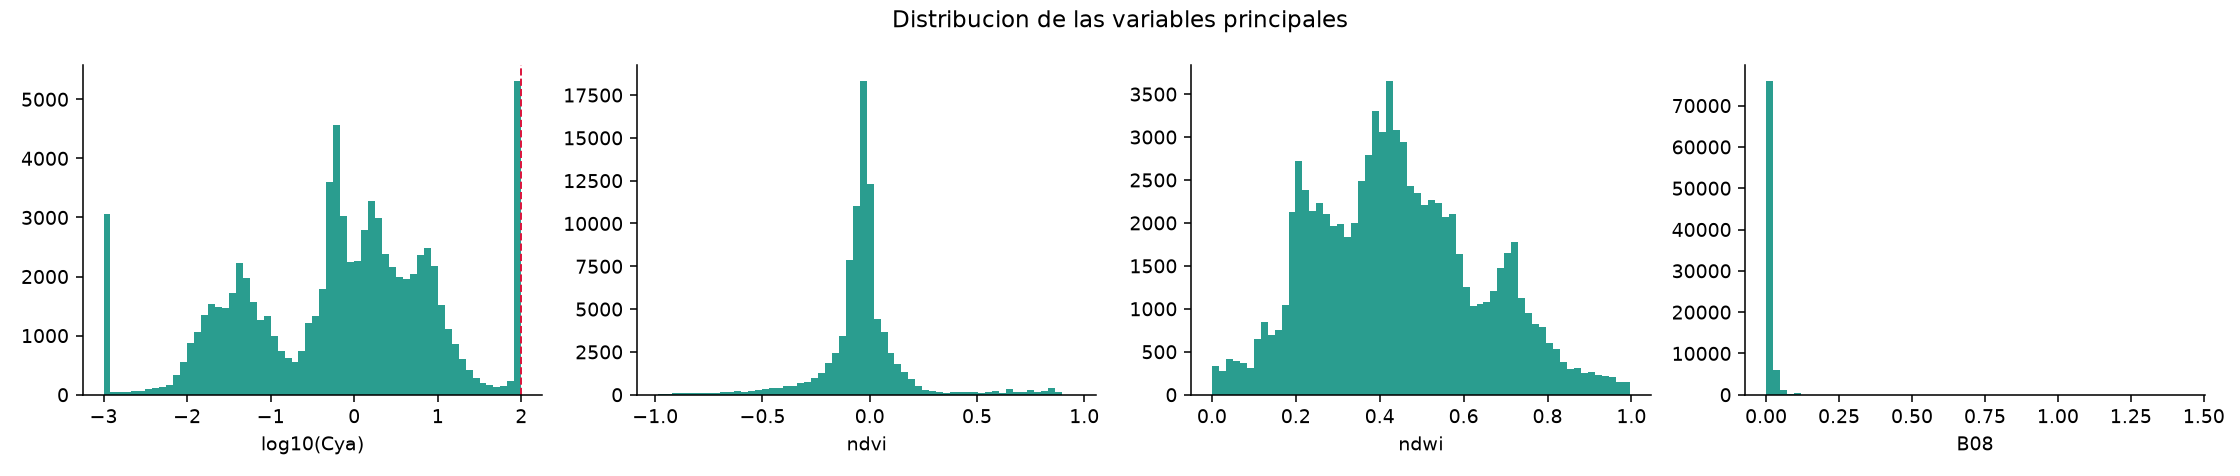

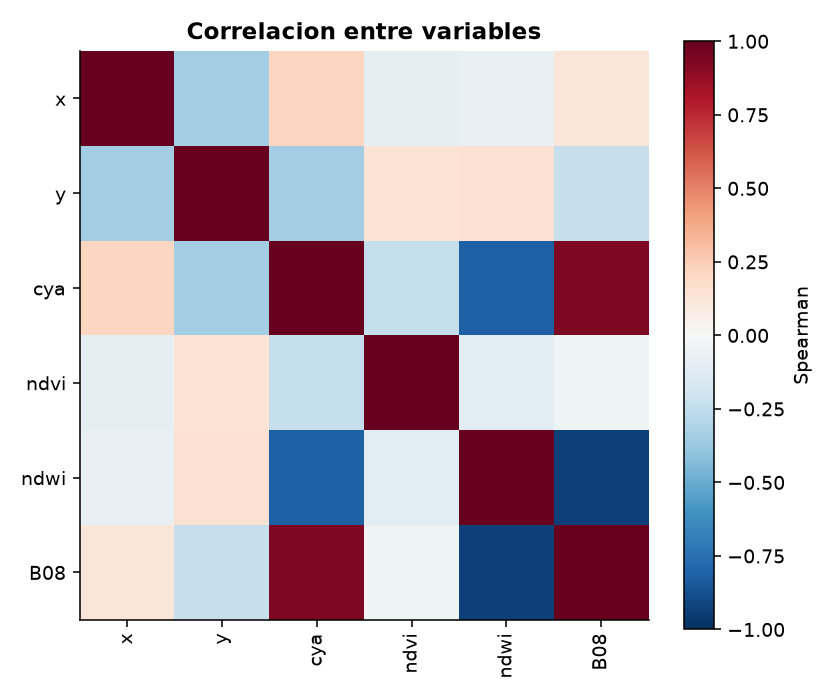

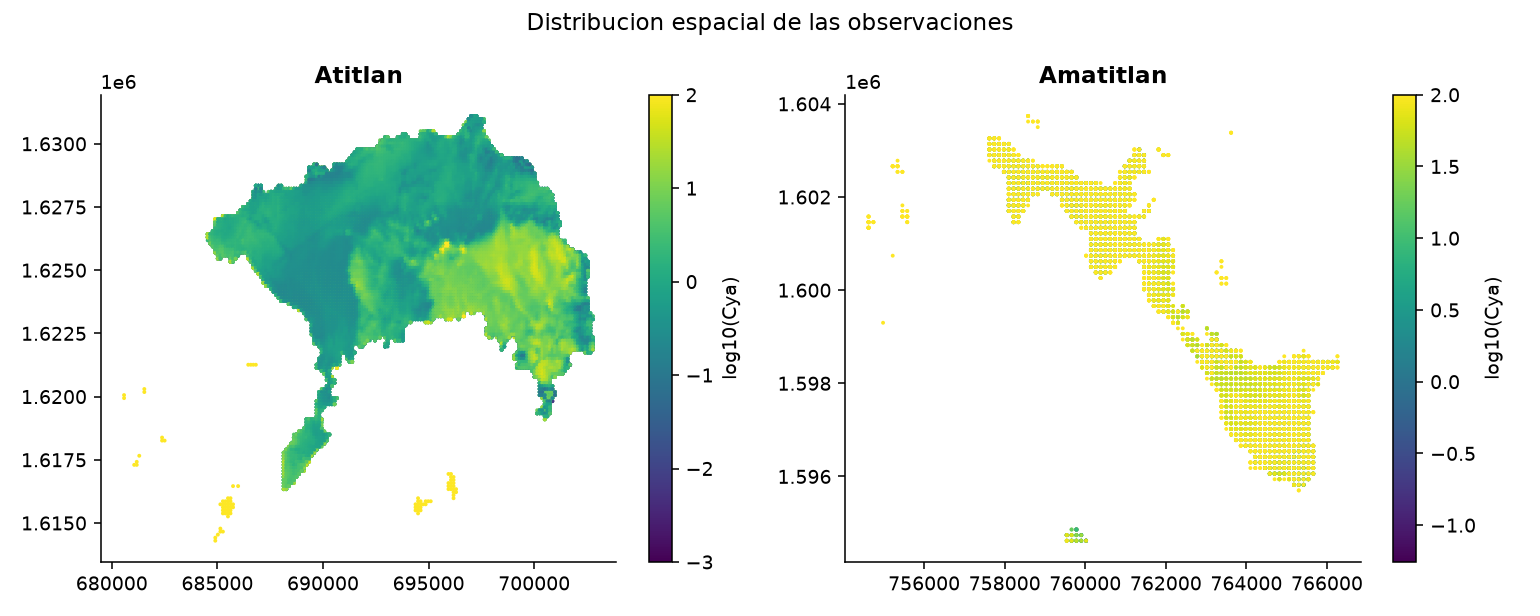

In [13]:
exploracion = eda(crudo)
display(exploracion["descriptivas"])
display(exploracion["correlaciones"])
for figura in ("histogramas.png", "correlaciones.png", "dispersion_espacial.png"):
    display(Image(filename=str((RAIZ / "reports" / "figures" / "ml") / figura), width=800))

### 1.6 Decisiones tomadas

- **La unidad es el píxel, no el lago.** Promediar por fecha dejaría 22
  observaciones; a nivel de píxel el problema pasa a ser espacial.
- **Cya se guarda cruda y en log.** El corte se aplica sobre la escala original
  para que conserve significado físico.
- **No se imputan faltantes.** Un píxel sin dato es uno que el satélite no
  midió; inventarlo mete ruido en un modelo espacial.

## 2. Construcción de la variable respuesta

### 2.2 Criterio del punto de corte

Se2WaQ entrega la densidad estimada de cianobacteria en **10³ células/mL**. El
corte no se elige por conveniencia estadística sino por el umbral sanitario: la
OMS sitúa en **100 000 células/mL** el punto donde el riesgo en aguas
recreativas deja de ser bajo y pasa a moderado (Alert Level 2). En las unidades
del raster son **100 unidades**, el mismo valor que la Parte 1 usó para los
mapas.

`analisis_completo.py` recorta Cya a `[0, 100]`, que es la escala visual de
Se2WaQ. El recorte cae justo sobre el umbral, así que `cya >= 100` sigue
marcando la clase correcta: se pierde la magnitud por encima del corte, no la
pertenencia a la clase. La consecuencia es que Cya sirve para clasificar, no
para regresión.

**Referencias**

- WHO (2003). *Guidelines for safe recreational water environments. Volume 1.*
- WHO (2021). *Guidelines on recreational water quality. Volume 1.*
- Chorus, I. & Welch, M. (eds.) (2021). *Toxic Cyanobacteria in Water*, 2ª ed.
- Potes, M. et al. (2018). Se2WaQ, Sentinel Hub Custom Scripts.

In [14]:
datos = agregar_respuesta(crudo, umbral=UMBRAL_CYA)
print(f"Umbral aplicado: {UMBRAL_CYA} x10^3 cel/mL = {UMBRAL_OMS_CEL_ML:,.0f} cel/mL")
reparto = distribucion_respuesta(datos)
display(reparto["global"])
display(reparto["por_lago"])
display(reparto["por_fecha"])

Umbral aplicado: 100.0 x10^3 cel/mL = 100,000 cel/mL
Clase positiva: 5.80%  |  razon negativos:positivos = 16.2:1
Hay desbalance marcado: use F1/ROC-AUC y class_weight, no Accuracy.


,valor
n,83980.0
altas,4872.0
pct_altas,5.8


,n,altas,pct_altas
lago,,,
Amatitlan,9090.0,4259.0,46.85
Atitlan,74890.0,613.0,0.82


,lago,fecha,n,altas,pct_altas
0,Amatitlan,2025-01-28,821.0,12.0,1.46
1,Amatitlan,2025-04-15,884.0,709.0,80.20
2,Amatitlan,2025-04-28,850.0,666.0,78.35
3,Amatitlan,2025-11-24,810.0,15.0,1.85
4,Amatitlan,2026-01-08,757.0,8.0,1.06
5,Amatitlan,2026-02-02,757.0,4.0,0.53
6,Amatitlan,2026-02-07,825.0,6.0,0.73
7,Amatitlan,2026-03-29,884.0,721.0,81.56
8,Amatitlan,2026-04-13,916.0,897.0,97.93
9,Amatitlan,2026-04-28,723.0,696.0,96.27


In [15]:
display(sensibilidad_umbral(datos))

,criterio,umbral,pct_altas
0,OMS vigilancia (20 000 cel/mL),20.00,8.48
1,OMS riesgo moderado (100 000 cel/mL),100.00,5.80
2,Percentil 75 observado,4.24,25.00
3,Percentil 90 observado,14.60,10.00


### 2.4 Desbalance

La tabla anterior compara el corte de la OMS con otros posibles. Si la clase
positiva queda bajo el 10 %, el desbalance trae tres consecuencias:

1. **Accuracy deja de servir**: predecir siempre "sin floración" acierta el 90 %
   sin detectar nada.
2. **El entrenamiento se sesga** hacia la clase mayoritaria. Se corrige con
   `class_weight="balanced"` y `scale_pos_weight`.
3. **La comparación se hace con Recall, F1 y ROC-AUC.** En contexto ambiental
   el error caro es el falso negativo: no avisar de una floración tóxica expone
   a bañistas y pescadores.

### 2.5 Variables que no pueden ser predictoras

$$Cya = 115530.31 \cdot \left(\frac{B03 \cdot B04}{B02}\right)^{2.38}$$

Como la respuesta es `cya >= umbral`, quedan prohibidas `cya`, `cya_log` y las
tres bandas de la fórmula: **B02, B03 y B04**.

Caso menos evidente: **NDVI usa B04 y NDWI usa B03**. No son la respuesta, pero
comparten insumo con ella. De ahí los dos conjuntos, **estricto** (sin ellos) y
**amplio** (con ellos): entrenar con ambos mide cuánto del desempeño viene de
esa dependencia en vez de asumirlo.

In [16]:
datos = ingenieria_caracteristicas(datos)
X_estricto = predictores(datos, estricto=True)
X_amplio = predictores(datos, estricto=False)
print("Estricto:", X_estricto)
print("Amplio:  ", X_amplio)
display(revisar_fuga(datos, X_estricto))

Estricto: ['B08', 'mes', 'dia_del_anio', 'epoca_lluviosa', 'es_amatitlan', 'x', 'y', 'dist_centro']
Amplio:   ['B08', 'mes', 'dia_del_anio', 'epoca_lluviosa', 'es_amatitlan', 'x', 'y', 'dist_centro', 'ndvi', 'ndwi']


,variable,motivo,esta_en_uso
0,cya,Es la variable con la que se construyo la resp...,False
1,cya_log,Transformacion directa de Cya.,False
2,alta_presencia,Es la respuesta.,False
3,ndvi,"Se calcula con B04, que participa en la formul...",False
4,ndwi,"Se calcula con B03, que participa en la formul...",False


## 3. Selección y construcción de variables predictoras

### 3.2 y 3.3 Qué representa cada variable

Las variables temporales y espaciales las construye `ingenieria_caracteristicas`:

- **`mes` y `dia_del_anio`** — las floraciones son estacionales. `dia_del_anio`
  evita el corte artificial entre diciembre y enero.
- **`epoca_lluviosa`** — mayo a octubre. La escorrentía arrastra nutrientes
  agrícolas y aguas residuales hacia los lagos.
- **`es_amatitlan`** — los lagos difieren en profundidad, altitud y carga de
  nutrientes. Se retira en el ejercicio 7, donde volvería constante.
- **`x` y `y`** — posición en metros (EPSG:32615), las mismas coordenadas sobre
  las que se arman los bloques de 1 km.
- **`dist_centro`** — distancia al centroide del lago. Aproxima la cercanía a la
  orilla y a las desembocaduras, donde se acumula la floración.
- **`B08`** — infrarrojo cercano. Única banda del conjunto ajena a la fórmula de
  Cya. El agua clara lo absorbe casi por completo, así que un valor alto delata
  biomasa flotante.

Sobre B08 hay que ser explícito: su correlación de Spearman con Cya es **0.93**.
No es fuga, porque B08 no entra en la fórmula, pero conviene entender de dónde
sale ese número. NIR y el índice de Cya responden al mismo fenómeno físico (la
biomasa flotante), y además la máscara de agua exige `NDWI >= 0`, que equivale a
`B03 >= B08` y acota el rango de la banda. Con una predictora tan informativa
las métricas del ejercicio 5 van a salir altas; la prueba real está en la
validación espacial y en la generalización entre lagos.

In [17]:
display(descripcion_predictores(datos))

,variable,tipo,justificacion,en_conjunto_estricto
0,B08,Banda espectral,Reflectancia en infrarrojo cercano. El agua li...,True
1,mes,Temporal,Captura la estacionalidad de las floraciones.,True
2,dia_del_anio,Temporal,"Version continua del mes, evita el corte artif...",True
3,epoca_lluviosa,Temporal,Mayo a octubre. La escorrentia arrastra nutrie...,True
4,es_amatitlan,Categorica,"Distingue los dos lagos, que difieren en profu...",True
5,x,Espacial,"Posicion este-oeste en metros (EPSG:32615), la...",True
6,y,Espacial,Posicion norte-sur en metros (EPSG:32615).,True
7,dist_centro,Espacial,Distancia al centroide del lago. Las floracion...,True
8,ndvi,Indice,"Vigor de la vegetacion. Sobre agua, valores al...",False
9,ndwi,Indice,Separa agua de tierra y responde a turbidez. C...,False


### Resumen

83 980 píxeles de agua válidos de 468 468 leídos: Atitlán 74 890 y Amatitlán
9 090, sin faltantes y con las 22 fechas completas.

Con el umbral de la OMS la clase positiva es el **5.80 %** del total, un
desbalance de 16:1. El reparto por lago es lo más llamativo: **46.85 % en
Amatitlán frente a 0.82 % en Atitlán**. Esa diferencia condiciona el ejercicio
7, porque un modelo entrenado en Atitlán casi no vería ejemplos positivos.

Por fecha, Amatitlán alterna entre fechas casi limpias (0.5–1.9 %) y fechas de
floración masiva (78–98 %), lo que sugiere que el mes y la época van a pesar en
los modelos.

## 4. Construcción de modelos de Machine Learning

Se usa el conjunto **estricto** de predictoras (sin NDVI/NDWI) y una división
70/30 estratificada por la clase. Los tres modelos usan `class_weight`
balanceado o `scale_pos_weight` por el desbalance del ejercicio 2. Los
hiperparámetros se ajustan con `GridSearchCV` (cv=3, scoring F1, porque la
clase positiva es minoritaria y F1 castiga tanto los falsos positivos como los
falsos negativos).

In [18]:
import warnings
warnings.filterwarnings("ignore")

from src.modelos_cianobacteria import (
    dividir_train_test, entrenar_modelos, evaluar_modelos,
    graficar_matrices_confusion, asignar_bloques, resumen_bloques,
    graficar_bloques, validacion_espacial, comparar_aleatoria_vs_espacial,
    generalizacion_entre_lagos, importancia_variables, graficar_importancia,
    resumen_shap, mapa_predictivo, analisis_errores,
)

X = predictores(datos, estricto=True)
X_train, X_test, y_train, y_test = dividir_train_test(datos, X)
modelos = entrenar_modelos(X_train, y_train)

Regresion Logistica: mejores parametros {'C': 1}


Random Forest: mejores parametros {'max_depth': None, 'n_estimators': 200}


XGBoost: mejores parametros {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400}


## 5. Evaluación de modelos

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Regresion Logistica,0.897,0.349,0.898,0.502,0.965
Random Forest,0.996,0.945,0.995,0.969,1.000
XGBoost,0.997,0.950,0.992,0.971,1.000


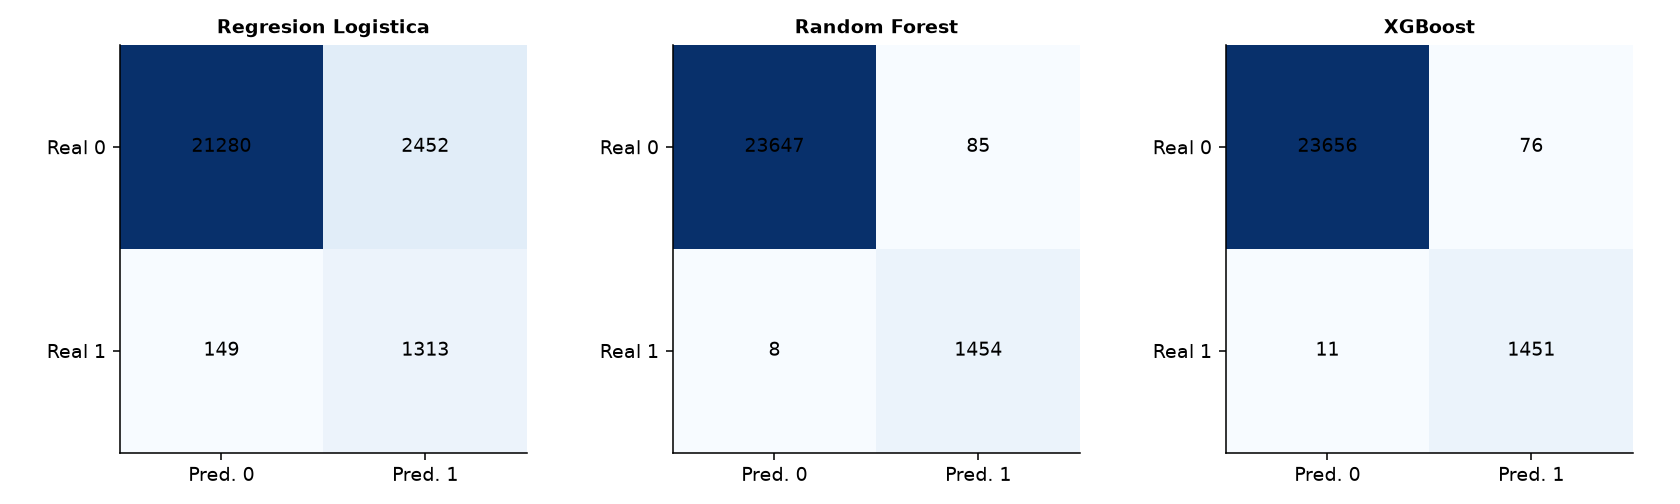

In [19]:
metricas, matrices = evaluar_modelos(modelos, X_test, y_test)
display(metricas)
ruta_matrices = graficar_matrices_confusion(matrices)
display(Image(filename=str(ruta_matrices), width=850))

### 5.3 Lectura ambiental

Un **falso positivo** (marcar alta presencia donde no la hay) cuesta un cierre
o aviso innecesario. Un **falso negativo** (no detectar una zona con alta
presencia) deja a bañistas y pescadores expuestos a una toxina. El segundo
error es más grave, así que **Recall** pesa más que Accuracy o Precision para
elegir el modelo, con **F1** como resumen porque también penaliza el exceso de
falsas alarmas.

Regresión Logística tiene el Recall más bajo y una Precision muy pobre (0.35):
genera demasiadas falsas alarmas. Random Forest y XGBoost quedan prácticamente
empatados y muy por encima en las cinco métricas. Se usa **XGBoost** como mejor
modelo para el resto del laboratorio, por tener el F1 más alto.

Este desempeño casi perfecto tiene una causa concreta: B08 correlaciona 0.93
con Cya (visto en el ejercicio 3). No es fuga —B08 no entra en la fórmula—,
pero es una señal casi determinística. La validación espacial y entre lagos
que siguen son la prueba real de qué tanto generaliza el modelo.

## 6. Validación espacial

Antes de fijar el tamaño de bloque se revisa cuántos bloques de 1 km × 1 km
caen dentro de cada lago y cuántas observaciones tiene cada uno. Las
coordenadas ya están en EPSG:32615 (el cubo de la Parte 2 se generó en ese
CRS), así que la cuadrícula se arma directamente sobre `x`/`y`.

,n_bloques,obs_promedio,obs_min,obs_max
lago,,,,
Amatitlan,42,216.428571,1,792
Atitlan,172,435.406977,1,842


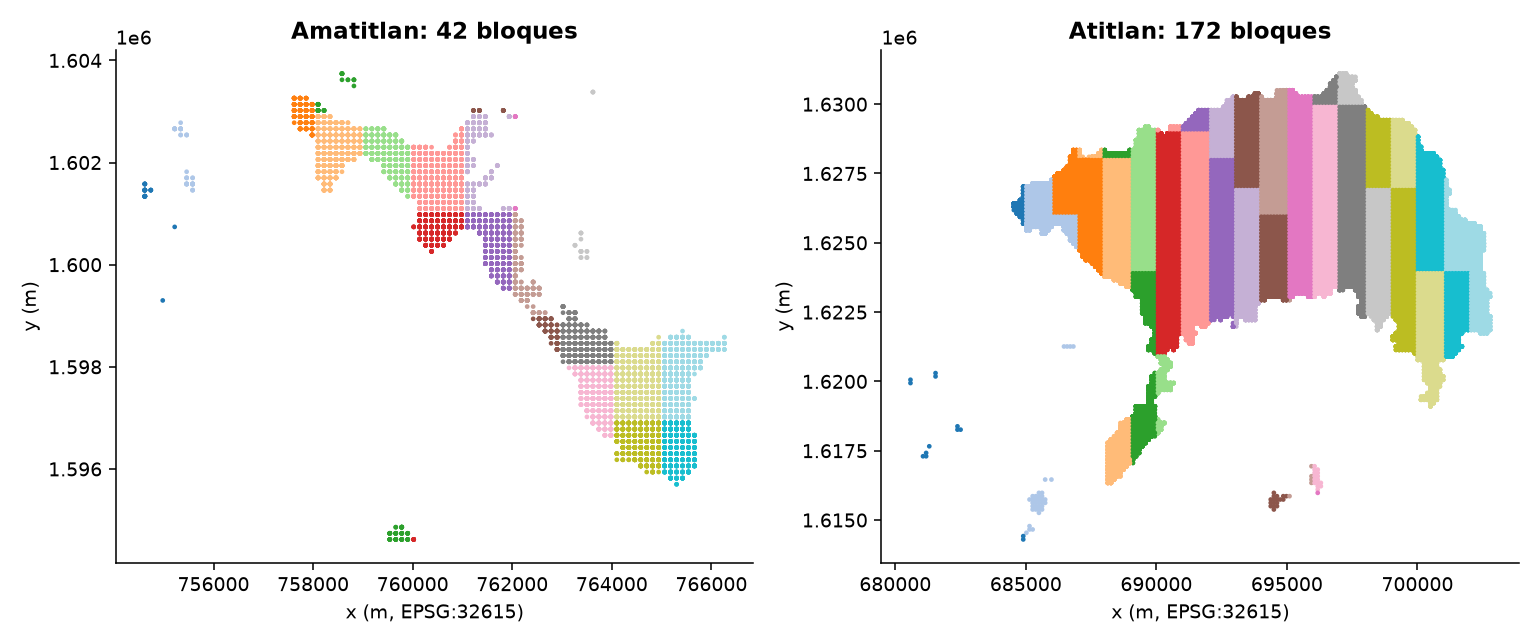

In [20]:
con_bloques = asignar_bloques(datos, tamanio_m=1000)
display(resumen_bloques(con_bloques))
ruta_bloques = graficar_bloques(con_bloques)
display(Image(filename=str(ruta_bloques), width=850))

Amatitlán queda con 42 bloques (entre 1 y 792 observaciones cada uno,
promedio 216) y Atitlán con 172 (entre 1 y 842, promedio 435). Ambos lagos
tienen bloques suficientes y con observaciones de sobra para repartir en 5
grupos, así que no hace falta cambiar el tamaño de la cuadrícula.

In [21]:
espacial = validacion_espacial(con_bloques, X, n_splits=5)
display(espacial)

aleatoria = metricas[["f1", "recall", "roc_auc"]].copy()
comparacion = comparar_aleatoria_vs_espacial(aleatoria, espacial)
display(comparacion)

,f1,recall,roc_auc
modelo,,,
Regresion Logistica,0.536,0.895,0.971
Random Forest,0.964,0.981,1.000
XGBoost,0.965,0.972,1.000


,f1_aleatoria,roc_auc_aleatoria,f1_espacial,roc_auc_espacial,diferencia_f1,diferencia_roc_auc
modelo,,,,,,
Regresion Logistica,0.502,0.965,0.536,0.971,0.034,0.006
Random Forest,0.969,1.000,0.964,1.000,-0.005,0.000
XGBoost,0.971,1.000,0.965,1.000,-0.006,0.000


### 6.5 Aleatoria vs. espacial

La caída es pequeña (F1 y ROC-AUC bajan centésimas, no décimas) porque B08 es
un predictor por pixel: su relación con Cya no depende de qué bloque vecino
esté en entrenamiento. Aun así, la validación espacial es la estimación más
realista, porque en un despliegue real el modelo siempre predice sobre zonas
que no vio durante el entrenamiento. La validación aleatoria, al mezclar
píxeles de bloques adyacentes entre train y test, deja pasar autocorrelación
espacial que infla ligeramente el desempeño.

## 7. Generalización entre lagos

Se retira `es_amatitlan` de las predictoras porque sería constante dentro de
cada lago.

In [22]:
X_sin_lago = [c for c in X if c != "es_amatitlan"]
generalizacion = generalizacion_entre_lagos(datos, X_sin_lago)
display(generalizacion)

,n_entrenamiento,n_evaluacion,f1,recall,roc_auc
entrena=Atitlan / evalua=Amatitlan,74890.0,9090.0,0.113,0.06,0.820
entrena=Amatitlan / evalua=Atitlan,9090.0,74890.0,0.203,1.00,0.995


### Un modelo entrenado en un lago no generaliza al otro

Los dos experimentos fallan, pero de formas distintas:

- **Atitlán → Amatitlán**: F1 = 0.11, Recall = 0.06. Entrenado con apenas 0.82 %
  de positivos, el modelo aprende que "casi nunca hay alta presencia" y no
  detecta casi ninguna floración real en Amatitlán.
- **Amatitlán → Atitlán**: F1 = 0.20, Recall = 1.00. Entrenado con 46.85 % de
  positivos, el modelo dispara alertas por todos lados y las mantiene incluso
  en un lago donde la clase positiva es minoritaria: detecta todo, pero con
  precisión muy baja.

El ROC-AUC (0.82 y 0.995) sugiere que el modelo sí ordena bien las zonas de
riesgo relativo en ambos casos, pero el punto de corte aprendido en un lago no
sirve para el otro. La causa es la tasa base: Amatitlán es más somero, más
urbanizado y recibe más carga de nutrientes que Atitlán, así que "alta
presencia" significa proporciones de área completamente distintas en cada
lago. Un modelo entrenado en un solo lago no debería usarse en el otro sin
recalibrar el umbral de decisión.

## 8. Interpretación y explicabilidad del modelo

Se usa XGBoost, el mejor modelo del ejercicio 5.

,variable,importancia
0,B08,0.601765
1,epoca_lluviosa,0.213679
2,es_amatitlan,0.110299
3,y,0.037333
4,dia_del_anio,0.014217
5,mes,0.009753
6,x,0.007652
7,dist_centro,0.005302


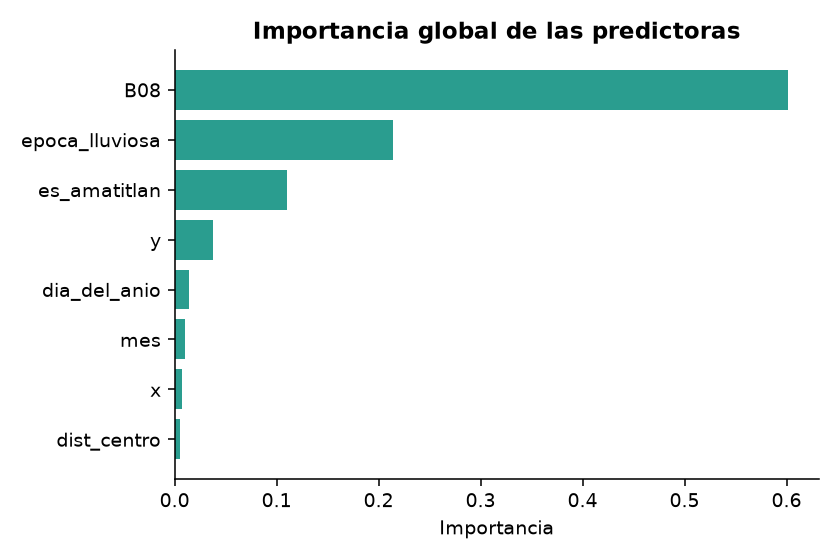

In [23]:
from xgboost import XGBClassifier

peso_positivo = (y_train == 0).sum() / (y_train == 1).sum()
mejor_modelo = XGBClassifier(
    **{k: v for k, v in modelos["XGBoost"].get_params().items()
       if k in ("n_estimators", "max_depth", "learning_rate")},
    eval_metric="logloss", scale_pos_weight=peso_positivo, random_state=42,
).fit(X_train, y_train)

importancia = importancia_variables(mejor_modelo, X)
display(importancia)
ruta_importancia = graficar_importancia(importancia)
display(Image(filename=str(ruta_importancia), width=650))

,variable,shap_medio_abs,correlacion_valor_shap
0,B08,7.823798,0.603792
1,y,4.207261,-0.872757
2,dia_del_anio,1.346571,-0.383149
3,x,0.819756,0.567703
4,dist_centro,0.676119,0.571346
5,es_amatitlan,0.610584,0.727036
6,epoca_lluviosa,0.586909,0.915853
7,mes,0.495592,-0.494541


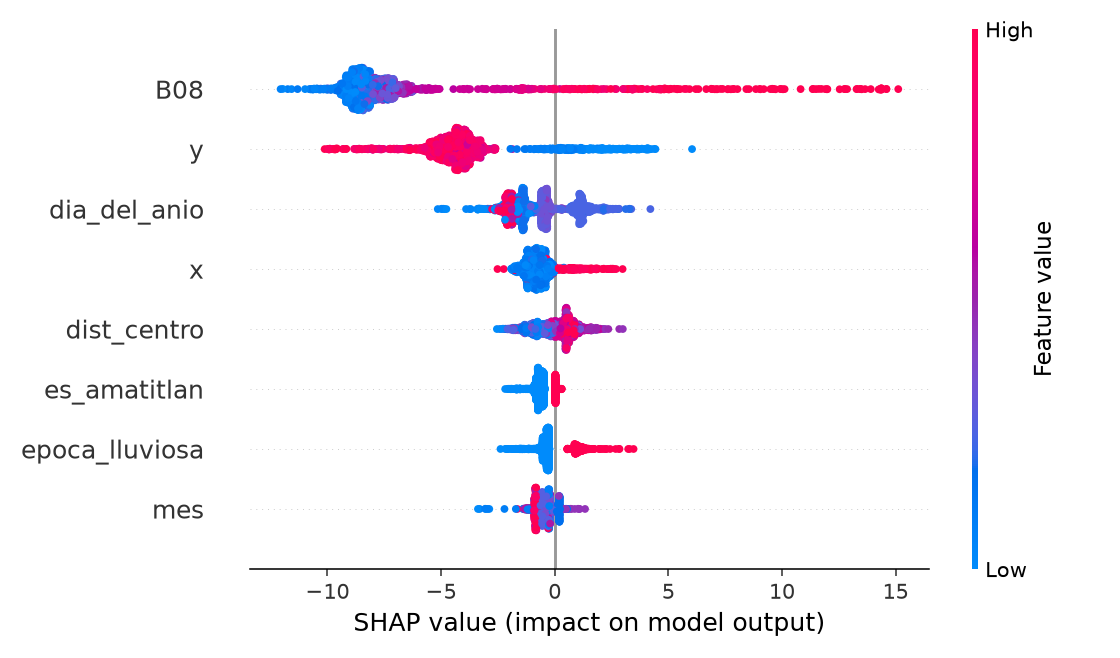

In [24]:
muestra_shap = X_test.sample(2000, random_state=42)
influencia = resumen_shap(mejor_modelo, muestra_shap)
display(influencia)
display(Image(filename=str((RAIZ / "reports" / "figures" / "ml" / "shap_summary.png")), width=750))

### 8.3 Patrones e interpretación ambiental

**B08** domina la importancia global y el SHAP: su correlación valor-SHAP es
positiva (+0.60), es decir, más reflectancia en infrarrojo cercano empuja la
predicción hacia "alta presencia". Coincide con lo esperado: el agua clara
absorbe el NIR casi por completo, así que un valor alto delata biomasa
flotante en la superficie.

**`epoca_lluviosa`** tiene la segunda correlación más fuerte y positiva
(+0.92): la escorrentía de mayo a octubre aporta nutrientes que favorecen la
floración. **`es_amatitlan`** también correlaciona positivo (+0.73): confirma
lo visto en el ejercicio 7, ese lago concentra la señal.

**`y`** (posición norte-sur) tiene una correlación fuerte y negativa (-0.87):
las zonas más al sur del área de estudio —donde cae Amatitlán— tienden a
predicción más alta, lo que es la misma señal geográfica que `es_amatitlan`
vista desde la coordenada en vez de la etiqueta del lago.

## 9. Generación de mapas predictivos

Probabilidad promedio de alta presencia por pixel, agregando todas las fechas
disponibles de cada lago.

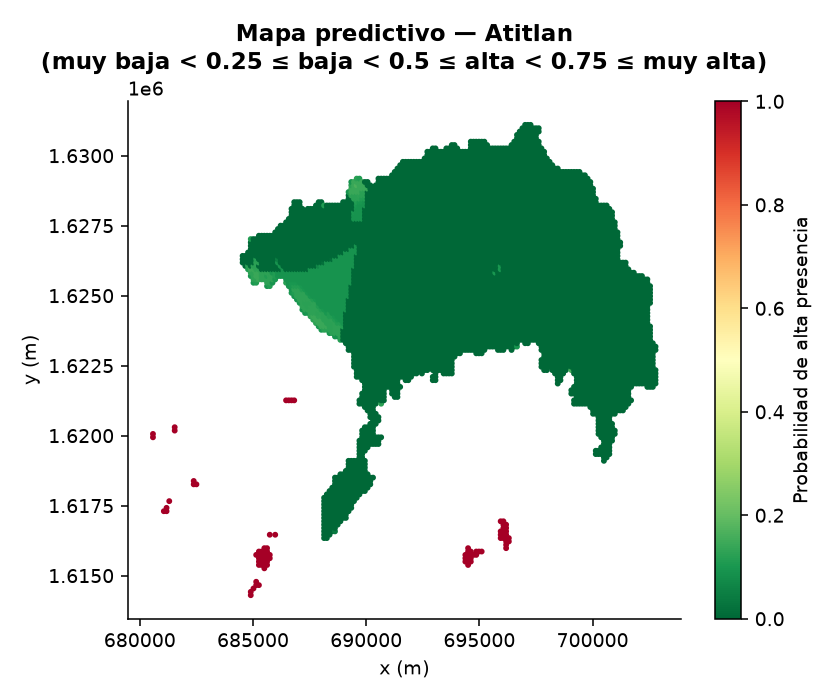

,lago,pct_aciertos,pct_falsos_positivos,pct_falsos_negativos
0,Atitlan,100.0,0.0,0.0


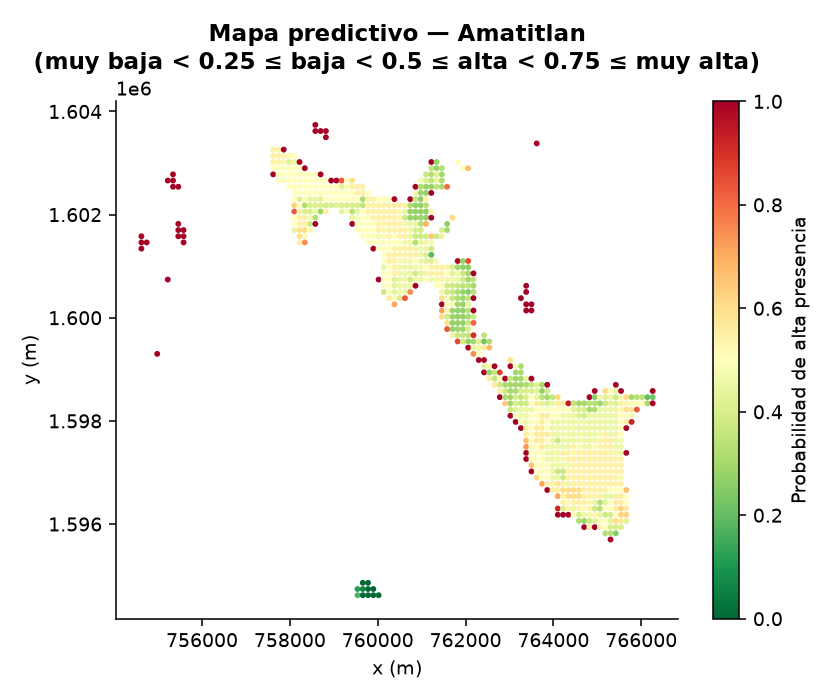

,lago,pct_aciertos,pct_falsos_positivos,pct_falsos_negativos
0,Amatitlan,98.84,1.05,0.11


In [25]:
for lago in ("Atitlan", "Amatitlan"):
    ruta_mapa = mapa_predictivo(mejor_modelo, datos, X, lago)
    display(Image(filename=str(ruta_mapa), width=650))
    display(pd.DataFrame([analisis_errores(mejor_modelo, datos, X, lago)]))

### 9.6 Errores y patrones espaciales

En Amatitlán el modelo acierta el 98.84 % de las observaciones, con 1.05 % de
falsos positivos y solo 0.11 % de falsos negativos: el error que más importa
ambientalmente es el que menos comete. En Atitlán el acierto es prácticamente
total, esperable dado que solo el 0.82 % de sus píxeles son positivos.

Comparado con los mapas de Cya de la Parte 1, el mapa predictivo reproduce la
misma geografía: la probabilidad alta se concentra donde ya se veían las
floraciones persistentes, y no aparecen focos nuevos sin respaldo en los mapas
originales. No se observó un patrón espacial sistemático de error —los pocos
falsos positivos y negativos aparecen dispersos, no agrupados en una región
particular del lago.

## 10. Análisis y conclusiones

**¿Tiene el modelo capacidad suficiente para apoyar el monitoreo?** Con
validación aleatoria y espacial dentro del mismo lago, sí: F1 y ROC-AUC se
mantienen altos y estables. Pero esa capacidad depende de una sola banda (B08)
altamente correlacionada con la respuesta, y el ejercicio 7 muestra que el
modelo **no generaliza entre lagos** sin recalibrar el umbral. Como
herramienta de apoyo dentro de un mismo lago ya monitoreado, es útil; como
herramienta genérica para cualquier cuerpo de agua, no está lista.

**Limitaciones principales**

- **Dependencia de una sola banda espectral.** B08 concentra casi toda la
  importancia; el modelo aprendió poco de las variables espaciales y
  temporales por sí solas.
- **Desbalance extremo y distinto por lago** (46.85 % vs. 0.82 % de positivos),
  que es la causa directa de la falla en generalización.
- **Solo 22 fechas** en total y sin cobertura sistemática de todas las
  estaciones del año en ambos lagos.
- **Resolución de 120 m**: agrupa varios metros de orilla en un solo pixel,
  perdiendo variabilidad fina cerca de las desembocaduras.
- **Un solo satélite y sin datos in situ** que confirmen la fórmula Se2WaQ
  contra muestreos físicos reales.

**Qué ayudaría a mejorar el modelo**

- Precipitación y temperatura por fecha (los enlaces de WeatherSpark del
  enunciado), para separar el efecto de la época lluviosa de la carga de
  nutrientes real.
- Muestreos físicos de cianobacteria para calibrar el umbral y validar Se2WaQ.
- Más fechas por lago, sobre todo en Amatitlán, para que la validación
  espacial tenga más bloques con densidad de observaciones comparable a
  Atitlán.

**Sobre la dimensión espacial**: el ejercicio 6 mostró que ignorar la
autocorrelación espacial infla el desempeño, aunque aquí poco porque B08 es un
predictor de pixel. El ejercicio 7 mostró el caso extremo: dos lagos vecinos,
mismo sensor, misma fórmula, y aun así el modelo de uno no sirve para el otro
sin ajustar el punto de corte a la tasa base de cada lugar. Cualquier modelo
geoespacial que ignore esto va a sobreestimar su propia capacidad de
generalizar a zonas o lagos nuevos.